# MACHINE LEARNING, ARTIFICIAL NEURAL NETWORK AND DEEP LEARNING - MOD. 1 FINAL PROJECT

_by: Colombo Giacomo 535630_

The aim of this project is to create a model that will predict the role of a player in a tchoukball team. The model will be trained on a dataset containing statistics of players from different teams and will be able to predict the role of a player.

First of all: what is tchoukball? Tchoukball is a fast-paced team sport that combines elements of handball, volleyball and squash. It is played indoors or outdoors on a rectangular court with a rebound frame (similar to a trampoline) placed at each end. Two teams of seven players each try to score points by throwing the ball at a rebound frame in such a way that it bounces back and lands on the floor outside the forbidden zone (a semicircle around the frame) without being caught by the defending team. Unlike many other sports, physical contact and interceptions are not allowed. This sport is born in the '70 in Switzerland and despite being a niche sport, it has a large following in Europe and Asia (particulary in Italy, Switzerland, Taiwan and Singapore).

In [211]:
import warnings
import missingno as msno
import pandas as pd
import numpy as np
import itertools
import shap

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer, MinMaxScaler
from sklearn.model_selection import (
    learning_curve, validation_curve, train_test_split,
    RandomizedSearchCV, cross_validate, RepeatedStratifiedKFold, StratifiedKFold
)
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    f1_score, silhouette_score, silhouette_samples,
    classification_report, ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn import set_config
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

from mlxtend.feature_selection import SequentialFeatureSelector as SFS

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as IMBPipeline

from scipy.stats import loguniform
import matplotlib.pyplot as plt
import matplotlib as mp

set_config(transform_output="pandas")
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

## DATA COLLECTION

Tchoukball is largerly unkown and so matches and statistics are not an easy thing to find. For this project I collect data from 4 different sources (the website of the Tchoukball Geneva Indoors tournament, an old drive that contains some statistics from the Saronno's club, some excel sheets that I made myself in the past years and some data that a friend of mine collect for the Ferrara's team) and each of them has a different format and a different set of features (sometimes related to each other, sometimes completely independent).
Consequentially, as the matrixes shows, there are many missing values to deal with in the dataset.

In [ ]:
data = pd.read_csv('data\\DFML1.csv', sep=";")

data

,PLAYER,SEX,SCORED_1_LINE,SCORED_2_LINE,SCORED,DEFENCE_0,DEFENCE_1,DEFENCE_2,DEFENCE_3,DEFENCE,...,%TRUE_SHOT_SCORED,POINT_ON_TEAM,DEFENCE_ON _TEAM,TRUE_POINT_ON_TEAM,VAL_OFF,VAL_DEF,VAL,VALPM,VAL_ON_TEAM,ROLE
0,Mariné,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pivot
1,Rion,0.0,NaN,NaN,8.0,NaN,NaN,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pivot
2,Hirlimann,0.0,NaN,NaN,8.0,NaN,NaN,NaN,NaN,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wing
3,Favre,0.0,NaN,NaN,18.0,NaN,NaN,NaN,NaN,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Wing
4,Marquis,0.0,NaN,NaN,2.0,NaN,NaN,NaN,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Pivot
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2444,Bruno,0.0,7.0,1.0,NaN,1.0,0.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,5.0,31.818.181.818.181.800,8.181.818.181.818.180,NaN,NaN,Wing
2445,Tomasi,0.0,3.0,0.0,NaN,3.0,1.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,-2.0,2.727.272.727.272.720,0.7272727272727271,NaN,NaN,Wing
2446,Produit,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,0.0,4.545.454.545.454.540,4.545.454.545.454.540,NaN,NaN,Pivot
2447,Newell,0.0,1.0,0.0,NaN,1.0,0.0,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,-1.0,36.363.636.363.636.300,26.363.636.363.636.300,NaN,NaN,Wing


<Axes: >

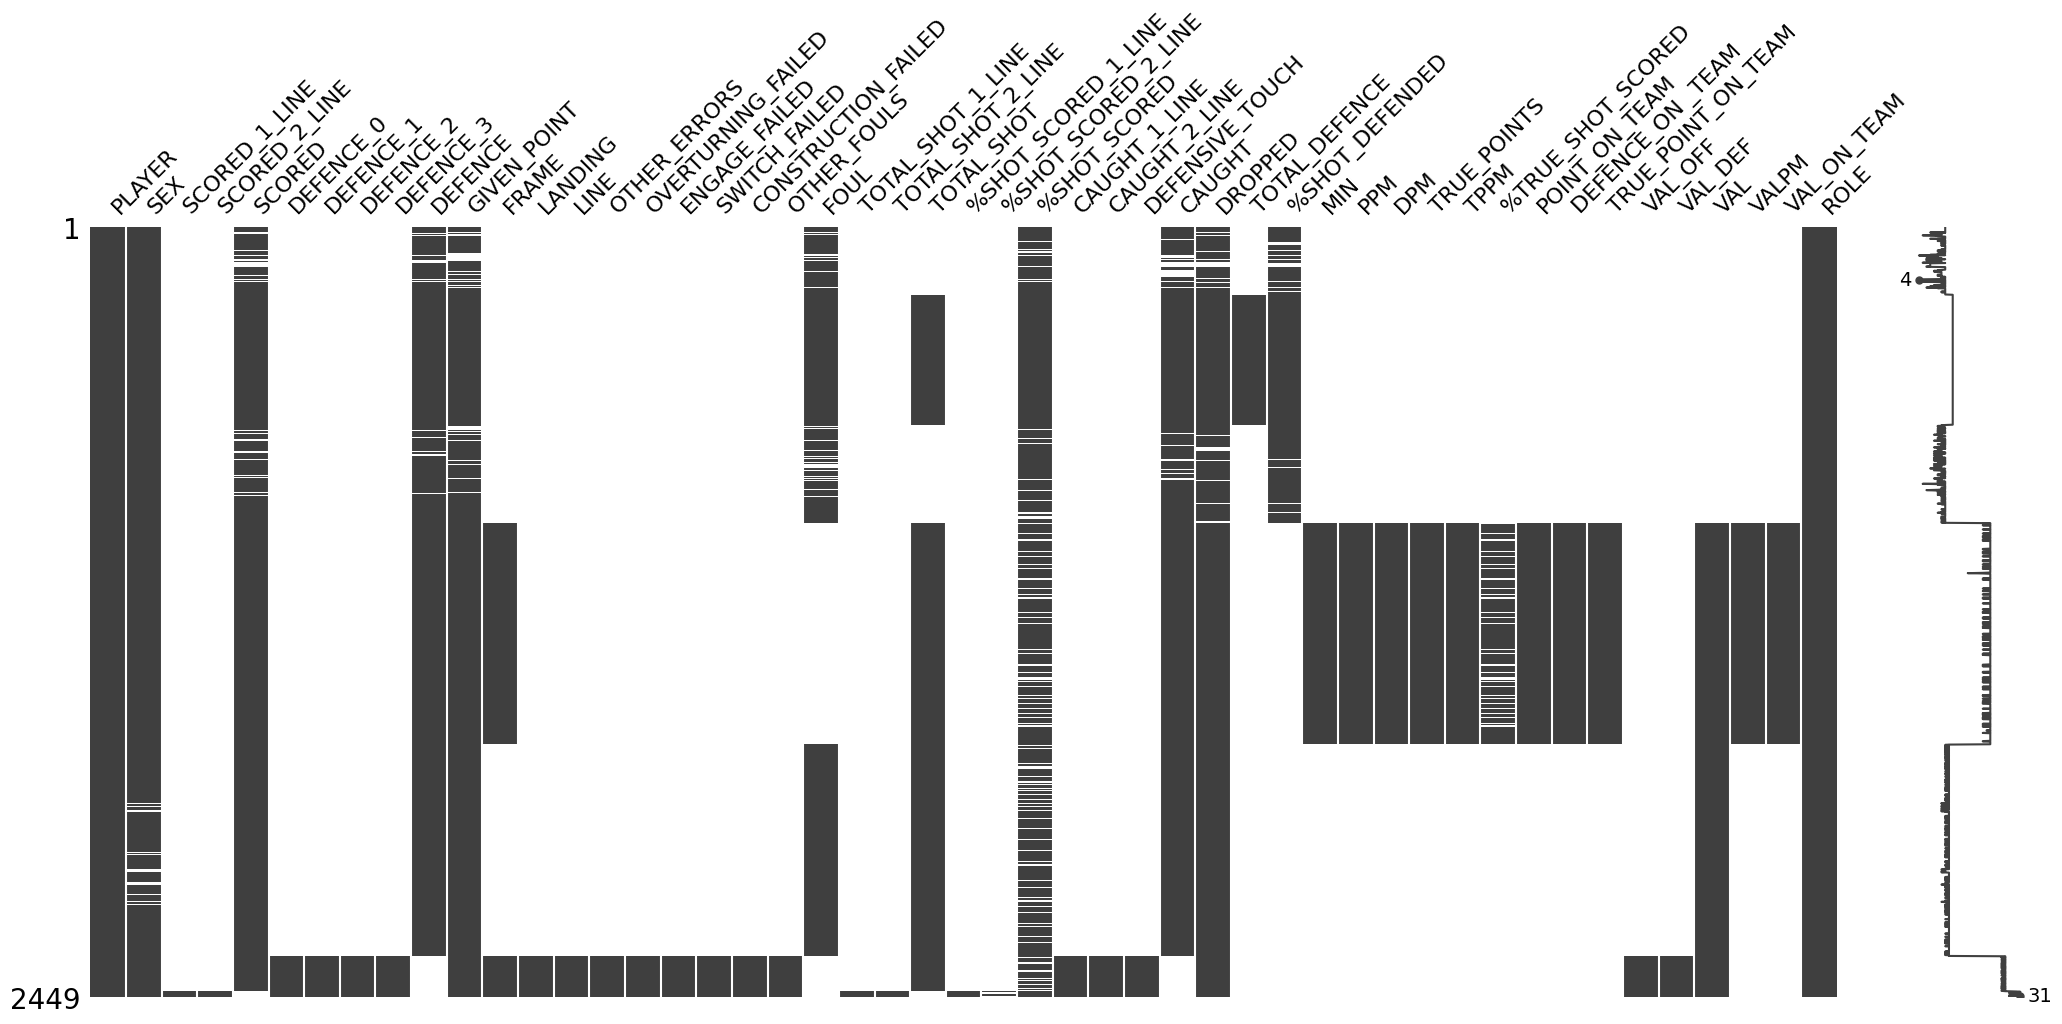

In [213]:
msno.matrix(data)

## FIRST STEP OF PREPROCESSING

For this project I decided to identify two main roles (so this is a single label binary classification problem): the Pivot (usually focused on the defending part and the construction of the plays) and the Wing (usually the scorers or the facilitators of the team). This division is really approximated cause in reality players are classified by their playstyle rather than on the position they play on the court, but for the purpose of this project I decided to simplify the problem.
As the numbers shows there is a little imbalance in the dataset that is due to the fact that on the court there are 4 Wings and 3 Pivots.

In [214]:
X = data.drop('ROLE', axis = 1)
y = data['ROLE']
y = y.map({'Pivot':0,'Wing':1})

y.value_counts()

,count
ROLE,
1,1462
0,987


## DATA PREPROCESSING & FEATURE ENGINEERING

In this phase:
1. **Metric Aggregation**: Subcomponents of the same metric are aggregated using fallback coalescing.
2. **Domain Feature Engineering**: Key efficiency ratios, net point contributions, and load-share metrics are computed directly on the dataset.


In [215]:
def compute_tchoukball_features(df):
    df_out = df.copy()

    if '%SHOT_SCORED' in df_out.columns:
        mask_dec = (df_out['%SHOT_SCORED'] > 0) & (df_out['%SHOT_SCORED'] <= 1.0)
        df_out.loc[mask_dec, '%SHOT_SCORED'] = df_out.loc[mask_dec, '%SHOT_SCORED'] * 100.0

    scored = pd.to_numeric(df_out.get('SCORED', 0), errors='coerce').fillna(0)
    defence = pd.to_numeric(df_out.get('DEFENCE', 0), errors='coerce').fillna(0)
    caught = pd.to_numeric(df_out.get('CAUGHT', 0), errors='coerce').fillna(0)
    dropped = pd.to_numeric(df_out.get('DROPPED', 0), errors='coerce').fillna(0)
    given_point = pd.to_numeric(df_out.get('GIVEN_POINT', 0), errors='coerce').fillna(0)
    foul = pd.to_numeric(df_out.get('FOUL', 0), errors='coerce').fillna(0)

    df_out['OFF_DEF_RATIO'] = scored / (caught + 1.0)
    df_out['CATCH_EFFICIENCY'] = caught / (caught + dropped + 1.0)
    df_out['NET_POINTS'] = scored - given_point

    total_involvement = scored + defence + caught + given_point + foul + 1.0
    df_out['OFF_LOAD_SHARE'] = scored / total_involvement
    df_out['ERROR_PRONENESS'] = (foul + given_point) / total_involvement


    return df_out, df

In [216]:
subcomponents = {
    'SCORED': ['SCORED_1_LINE', 'SCORED_2_LINE'],
    'DEFENCE': ['DEFENCE_0', 'DEFENCE_1', 'DEFENCE_2', 'DEFENCE_3'],
    'FOUL': ['FRAME', 'LANDING', 'LINE', 'OTHER_ERRORS', 'OVERTURNING_FAILED', 'ENGAGE_FAILED', 'SWITCH_FAILED', 'CONSTRUCTION_FAILED', 'OTHER_FOULS'],
    'CAUGHT': ['CAUGHT_1_LINE', 'CAUGHT_2_LINE', 'DEFENSIVE_TOUCH'],
}
for target, subcols in subcomponents.items():
    sum_sub = X[subcols].sum(axis=1, skipna=True).where(X[subcols].notna().any(axis=1))
    X[target] = X[target].fillna(sum_sub)

X_advanced, X = compute_tchoukball_features(X)

<Axes: >

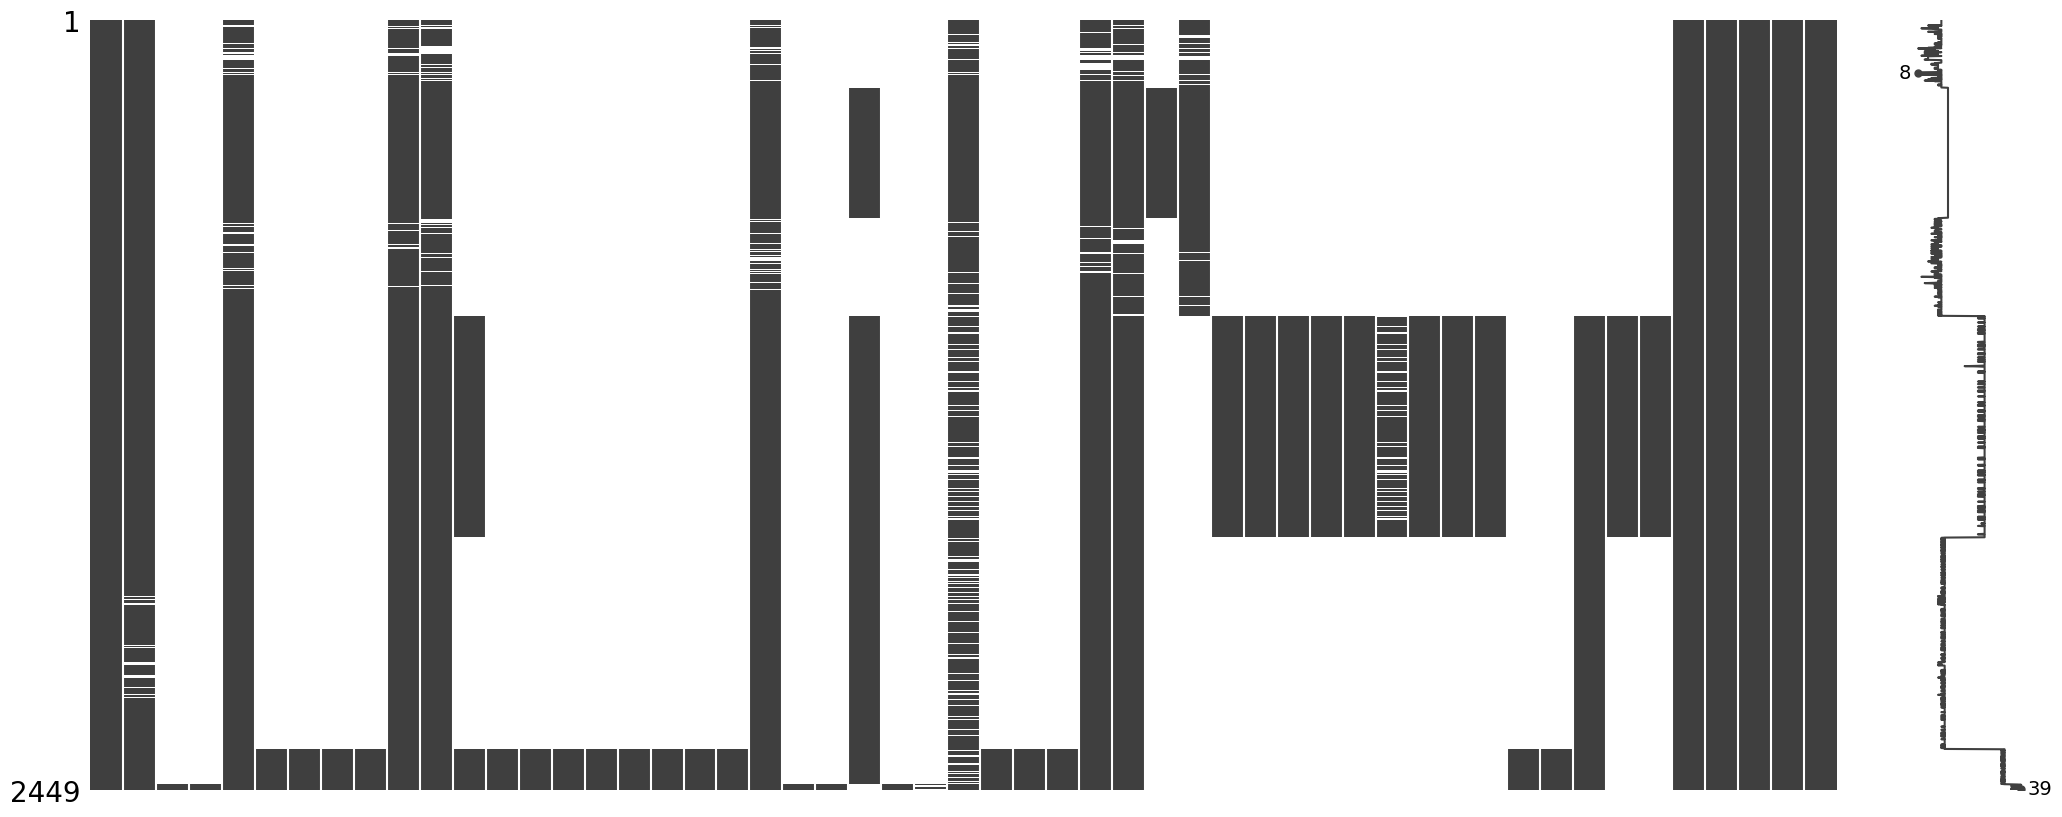

In [217]:
msno.matrix(X_advanced)

<Axes: >

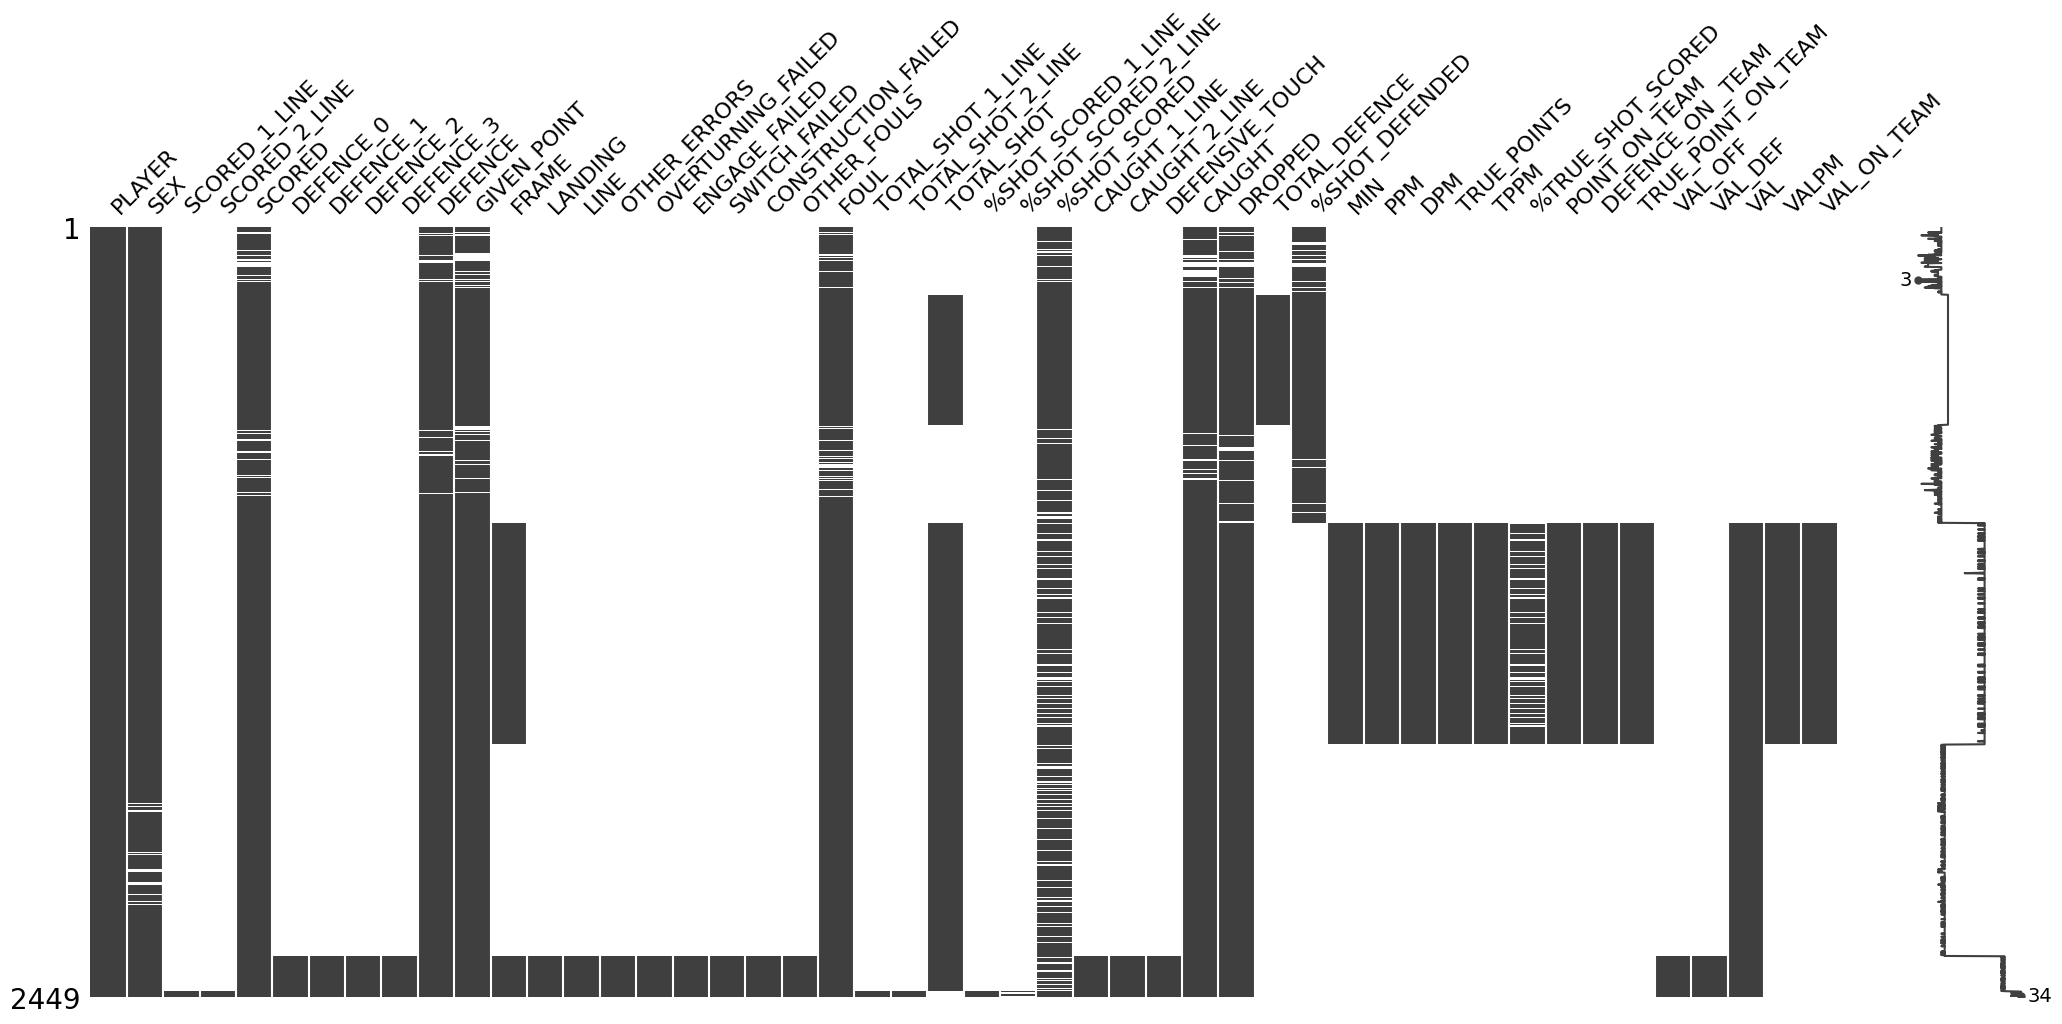

In [218]:
msno.matrix(X)

## DEFINITION OF THE DATA TRANSFORMATION PIPELINE

The data transformation pipeline uses a flat `ColumnTransformer` with dedicated imputation and scaling strategies:
1. **Percentages (`%SHOT_SCORED`)**: Constant imputer (`0`) and `StandardScaler` (since 0 indicates no shots attempted).
2. **Counts & Domain Ratios**: Median imputer and `StandardScaler` for volumetric and engineered ratio metrics.


In [219]:
feature_cols_pct = ['%SHOT_SCORED']

feature_cols_advanced = [
    'SCORED', 'DEFENCE', 'GIVEN_POINT', 'FOUL', 'CAUGHT', 'DROPPED',
    'OFF_DEF_RATIO', 'CATCH_EFFICIENCY',
    'NET_POINTS', 'OFF_LOAD_SHARE', 'ERROR_PRONENESS'
]

feature_cols_rest = [
  'SCORED', 'DEFENCE', 'GIVEN_POINT', 'FOUL', 'CAUGHT', 'DROPPED'
]

feature_cols_sex = ['SEX']

pipeline_percentage = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('scaler', StandardScaler())
])

pipeline_rest = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

pipeline_sex = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

In [220]:
final_transformation_advanced = ColumnTransformer(
    transformers=[
        ('pct', pipeline_percentage, feature_cols_pct),
        ('rest', pipeline_rest, feature_cols_advanced),
        ('sex', pipeline_sex, feature_cols_sex)
    ],
    remainder='drop',
    verbose_feature_names_out=False,
    sparse_threshold=0
)

final_transformation = ColumnTransformer(
    transformers=[
        ('pct', pipeline_percentage, feature_cols_pct),
        ('rest', pipeline_rest, feature_cols_rest),
        ('sex', pipeline_sex, feature_cols_sex)
    ],
    remainder='drop',
    verbose_feature_names_out=False,
    sparse_threshold=0
)

Here the train and the test are separated (30% of the original dataset is used for the test), there is a stratification on y (to prevent the test set to be too unbalanced) and a shuffle (to prevent the test set to be too similar to the train set because the data are ordered).

In [221]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify = y, random_state=RANDOM_STATE, shuffle=True)

In [222]:
X_advanced_train, X_advanced_test, y_train, y_test = train_test_split(X_advanced, y, test_size=0.3, stratify = y, random_state=RANDOM_STATE, shuffle=True)

We define a baseline model pipeline that incorporates `final_transformation` as its first step, followed by sampling, dimensionality reduction, and the classifier. This encapsulates the entire transformation workflow to prevent data leakage during cross-validation.


In [223]:
model_pipeline_advanced = IMBPipeline([
    ('trans', final_transformation_advanced),
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('dim_reduction', PCA(random_state=RANDOM_STATE, n_components=0.8)),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

model_pipeline = IMBPipeline([
    ('trans', final_transformation),
    ('sampler', SMOTE(random_state=RANDOM_STATE)),
    ('dim_reduction', PCA(random_state=RANDOM_STATE, n_components=0.8)),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

In [224]:
model_pipeline_advanced.fit(X_advanced_train,y_train)

Pipeline(steps=[('trans',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('pct',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['%SHOT_SCORED']),
                                                 ('rest',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SCORED', 'DEFENCE',
                                                   'GIVEN_POINT', 'FOUL',
                                                   'CA...
                                                   'OFF_DEF_RATIO',
                                                   'CATCH_EFFICIENCY',
                                                   'NET_POINTS',
                                                   'OFF_LOAD_SHARE',
                                                   'ERROR_PRONENESS']),
                                                 ('sex',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['SEX'])],
                                   verbose_feature_names_out=False)),
                ('sampler', SMOTE(random_state=42)),
                ('dim_reduction', PCA(n_components=0.8, random_state=42)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [225]:
model_pipeline_advanced.predict(X_advanced_test)

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,

In [226]:
model_pipeline.fit(X_train,y_train)

Pipeline(steps=[('trans',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('pct',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['%SHOT_SCORED']),
                                                 ('rest',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SCORED', 'DEFENCE',
                                                   'GIVEN_POINT', 'FOUL',
                                                   'CAUGHT', 'DROPPED']),
                                                 ('sex',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['SEX'])],
                                   verbose_feature_names_out=False)),
                ('sampler', SMOTE(random_state=42)),
                ('dim_reduction', PCA(n_components=0.8, random_state=42)),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [227]:
model_pipeline.predict(X_test)

array([1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1,
       0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 1,

## MODEL SELECTION

Now that all seems to work, it is possible to define the hyperparameters for the optimization phase of the model selection.

I decided to use a RandomizedSearchCV with a cross validation of 2 and a scoring of 'f1' to find the best model.
The candidates are the following:

1. For the sampler: None (this passage is skipped), SMOTE (that synthetize elements for the minority class) and RandomOverSampler (that repeat some instances of the minority class).
2. For dimensionality reduction: None (the passage is skipped), PCA (that reduce the dimention through a linear transformation thanks to the eigenvalues of the covariance matrix), LDA (that is similar to the PCA but it takes into account the labels) and SFS (that reduce the dimension through a sequential feature selection)
3. For the classifier: Perceptron (a simple linear classifier), LogisticRegression (that works with probabilities to classify instances), KNeighborsClassifier (that uses the distance between instances to classify them), RandomForestClassifier (an ensemble method that uses many decision trees) and XGBClassifier (another ensemble method that uses also gradient boosting to improve the performance).


In [228]:
sampler_configs = [
    {
        'sampler':[None]
    },
    {
        'sampler':[SMOTE()],
        'sampler__sampling_strategy':['minority', 1.2, 0.9, 0.7]
    },
    {
        'sampler':[RandomOverSampler()],
        'sampler__sampling_strategy':['minority', 1.2, 0.9, 0.7]
    }
]

dim_reduction_configs = [
    {
        'dim_reduction': [None]
    },
    {
        'dim_reduction': [PCA()],
        'dim_reduction__n_components': [0.5, 0.7, 0.9]
    },
    {
        'dim_reduction': [LDA()]
    },
    {
        'dim_reduction': [SFS(estimator=Perceptron(), cv = None, scoring = 'f1')],
        'dim_reduction__estimator': [Perceptron(), LogisticRegression()],
        'dim_reduction__k_features' : [3, 5, 7],
        'dim_reduction__forward': [True, False]
    }
]

classifier_configs = [
    {
        'classifier': [LogisticRegression()],
        'classifier__C' : loguniform(0.001,100),
        'classifier__penalty': ['l1','l2'],
        'classifier__class_weight' : [None, 'balanced'],
        'classifier__max_iter': [1,5,10,15,50,100],
        'classifier__solver': ['saga', 'liblinear']

    },
    {
        'classifier': [KNeighborsClassifier()],
        'classifier__n_neighbors': [3,5,7,9],
        'classifier__algorithm': ['auto', 'kd_tree']
    },
    {
        'classifier' : [RandomForestClassifier()],
        'classifier__n_estimators' : [10,50,100, 500],
        'classifier__criterion': ['gini', 'entropy']
    },
    {
        'classifier' : [XGBClassifier()],
        'classifier__n_estimators' : [10,50,100, 500],
        'classifier__learning_rate': [0.001, 0.01, 0.1, 1]
    }
]

Now it's time to build the effective RandomSearchCV by combining all the possible confguration and then use nested-cross validation to find 5 different candidates that could be good for the final model.

In [229]:
all_configs = []
for configuration in itertools.product(sampler_configs,dim_reduction_configs,classifier_configs):
    all_parameters = []
    for element in configuration:
        for item in element.items():
            all_parameters.append(item)
    all_configs.append(dict(all_parameters))

In [230]:
f'Number of all possible configurations: {len(all_configs)}'

'Number of all possible configurations: 48'

In [231]:
rs_advanced = RandomizedSearchCV(model_pipeline_advanced,
    param_distributions=all_configs,
    n_iter=len(all_configs) * 5,
    n_jobs=-1,
    cv = 2,
    scoring='f1'
)

rs = RandomizedSearchCV(model_pipeline,
    param_distributions=all_configs,
    n_iter=len(all_configs) * 5,
    n_jobs=-1,
    cv = 2,
    scoring='f1'
)

In [232]:
scores_advanced = cross_validate(rs_advanced, X_advanced_train, y_train, scoring='f1', cv = 5, return_estimator=True, verbose=3)

[CV] END ......................................., score=0.888 total time= 1.8min
[CV] END ......................................., score=0.873 total time= 1.4min
[CV] END ......................................., score=0.896 total time= 1.3min
[CV] END ......................................., score=0.870 total time= 1.5min
[CV] END ......................................., score=0.882 total time= 1.6min


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  7.7min finished


In [233]:
def get_step_name(step):
    if step is None:
        return 'None'
    return type(step).__name__

results_advanced = []
for fold_idx, estimator in enumerate(scores_advanced['estimator']):
    best = estimator.best_estimator_
    clf = best.named_steps['classifier']
    sampler = best.named_steps.get('sampler')
    dim_red = best.named_steps.get('dim_reduction')

    f1_train = f1_score(y_train, best.predict(X_advanced_train))
    f1_test = f1_score(y_test, best.predict(X_advanced_test))

    results_advanced.append({
        'fold': fold_idx,
        'classifier': type(clf).__name__,
        'sampler': get_step_name(sampler),
        'dim_reduction': get_step_name(dim_red),
        'outer_cv_f1': scores_advanced['test_score'][fold_idx],
        'f1_train': f1_train,
        'f1_test': f1_test,
        'overfit_gap': f1_train - f1_test
    })

results_advanced_df = pd.DataFrame(results_advanced)

summary_advanced = results_advanced_df.groupby('classifier').agg(
    mean_outer_f1=('outer_cv_f1', 'mean'),
    std_outer_f1=('outer_cv_f1', 'std'),
    mean_f1_test=('f1_test', 'mean'),
    mean_gap=('overfit_gap', 'mean'),
    n_folds=('fold', 'count')
).sort_values('mean_f1_test', ascending=False)

summary_advanced

,mean_outer_f1,std_outer_f1,mean_f1_test,mean_gap,n_folds
classifier,,,,,
LogisticRegression,0.881992,0.01091,0.876921,0.011984,5


In [234]:
scores = cross_validate(rs, X_train, y_train, scoring='f1', cv = 5, return_estimator=True, verbose=3)

[CV] END ......................................., score=0.892 total time= 1.1min
[CV] END ......................................., score=0.893 total time= 1.4min
[CV] END ......................................., score=0.888 total time= 1.5min
[CV] END ......................................., score=0.875 total time= 1.3min
[CV] END ......................................., score=0.897 total time= 1.3min


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed:  6.5min finished


In [235]:
def get_step_name(step):
    if step is None:
        return 'None'
    return type(step).__name__

results = []
for fold_idx, estimator in enumerate(scores['estimator']):
    best = estimator.best_estimator_
    clf = best.named_steps['classifier']
    sampler = best.named_steps.get('sampler')
    dim_red = best.named_steps.get('dim_reduction')

    f1_train = f1_score(y_train, best.predict(X_train))
    f1_test = f1_score(y_test, best.predict(X_test))

    results.append({
        'fold': fold_idx,
        'classifier': type(clf).__name__,
        'sampler': get_step_name(sampler),
        'dim_reduction': get_step_name(dim_red),
        'outer_cv_f1': scores['test_score'][fold_idx],
        'f1_train': f1_train,
        'f1_test': f1_test,
        'overfit_gap': f1_train - f1_test
    })

results_df = pd.DataFrame(results)

summary = results_df.groupby('classifier').agg(
    mean_outer_f1=('outer_cv_f1', 'mean'),
    std_outer_f1=('outer_cv_f1', 'std'),
    mean_f1_test=('f1_test', 'mean'),
    mean_gap=('overfit_gap', 'mean'),
    n_folds=('fold', 'count')
).sort_values('mean_f1_test', ascending=False)

summary

,mean_outer_f1,std_outer_f1,mean_f1_test,mean_gap,n_folds
classifier,,,,,
XGBClassifier,0.897375,NaN,0.877778,0.053875,1
RandomForestClassifier,0.888372,NaN,0.874058,0.094934,1
LogisticRegression,0.886889,0.010045,0.873884,0.016947,3


##REFINEMENT OF THE SELECTED MODEL

From the nested-cross validation I decide to keep the LogisticRegression classifier even if also all the other candidates have good performance (really outstanding on the test with XGBClassifier).

Then the hyperparameters are refined using another RandomizedSearchCV aiming to identify the best configuration for the LogisticRegression classifier.

In [236]:
best_model_pipeline_advanced = IMBPipeline([
    ('trans', final_transformation_advanced),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

best_model_pipeline = IMBPipeline([
    ('trans', final_transformation),
    ('classifier', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000))
])

In [237]:
params = {
    'classifier__C': loguniform(1e-3, 1e2),
    'classifier__solver': ['liblinear', 'saga'],
    'classifier__penalty': ['l1', 'l2']
}

In [238]:
rs_best_advanced = RandomizedSearchCV(
    estimator = best_model_pipeline_advanced,
    param_distributions = params,
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=RANDOM_STATE),
    n_iter=20,
    error_score='raise',
    scoring='f1',
    random_state=RANDOM_STATE
)

rs_best = RandomizedSearchCV(
    estimator = best_model_pipeline,
    param_distributions = params,
    cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=1, random_state=RANDOM_STATE),
    n_iter=20,
    error_score='raise',
    scoring='f1',
    random_state=RANDOM_STATE
)

In [239]:
rs_best_advanced.fit(X_advanced_train, y_train)

RandomizedSearchCV(cv=RepeatedStratifiedKFold(n_repeats=1, n_splits=5, random_state=42),
                   error_score='raise',
                   estimator=Pipeline(steps=[('trans',
                                              ColumnTransformer(sparse_threshold=0,
                                                                transformers=[('pct',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(fill_value=0,
                                                                                                              strategy='constant')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['%SHOT_SCORED']),
                                                                              ('rest',
                                                                               Pipeline(steps=[('i...
                                                                                                SimpleImputer(strategy='most_frequent'))]),
                                                                               ['SEX'])],
                                                                verbose_feature_names_out=False)),
                                             ('classifier',
                                              LogisticRegression(max_iter=1000,
                                                                 random_state=42))]),
                   n_iter=20,
                   param_distributions={'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ba439ecba10>,
                                        'classifier__penalty': ['l1', 'l2'],
                                        'classifier__solver': ['liblinear',
                                                               'saga']},
                   random_state=42, scoring='f1')

In [240]:
rs_best.fit(X_train, y_train)

RandomizedSearchCV(cv=RepeatedStratifiedKFold(n_repeats=1, n_splits=5, random_state=42),
                   error_score='raise',
                   estimator=Pipeline(steps=[('trans',
                                              ColumnTransformer(sparse_threshold=0,
                                                                transformers=[('pct',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(fill_value=0,
                                                                                                              strategy='constant')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['%SHOT_SCORED']),
                                                                              ('rest',
                                                                               Pipeline(steps=[('i...
                                                                                                SimpleImputer(strategy='most_frequent'))]),
                                                                               ['SEX'])],
                                                                verbose_feature_names_out=False)),
                                             ('classifier',
                                              LogisticRegression(max_iter=1000,
                                                                 random_state=42))]),
                   n_iter=20,
                   param_distributions={'classifier__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7ba439ecba10>,
                                        'classifier__penalty': ['l1', 'l2'],
                                        'classifier__solver': ['liblinear',
                                                               'saga']},
                   random_state=42, scoring='f1')

In [241]:
rs_best_advanced.best_estimator_

Pipeline(steps=[('trans',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('pct',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['%SHOT_SCORED']),
                                                 ('rest',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SCORED', 'DEFENCE',
                                                   'GIVEN_POINT', 'FOUL',
                                                   'CA...', 'DROPPED',
                                                   'OFF_DEF_RATIO',
                                                   'CATCH_EFFICIENCY',
                                                   'NET_POINTS',
                                                   'OFF_LOAD_SHARE',
                                                   'ERROR_PRONENESS']),
                                                 ('sex',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['SEX'])],
                                   verbose_feature_names_out=False)),
                ('classifier',
                 LogisticRegression(C=np.float64(0.14445251022763064),
                                    max_iter=1000, penalty='l1',
                                    random_state=42, solver='liblinear'))])

In [242]:
rs_best.best_estimator_

Pipeline(steps=[('trans',
                 ColumnTransformer(sparse_threshold=0,
                                   transformers=[('pct',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value=0,
                                                                                 strategy='constant')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['%SHOT_SCORED']),
                                                 ('rest',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['SCORED', 'DEFENCE',
                                                   'GIVEN_POINT', 'FOUL',
                                                   'CAUGHT', 'DROPPED']),
                                                 ('sex',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent'))]),
                                                  ['SEX'])],
                                   verbose_feature_names_out=False)),
                ('classifier',
                 LogisticRegression(C=np.float64(0.033205591037519584),
                                    max_iter=1000, random_state=42,
                                    solver='liblinear'))])

In [243]:
f1_score(y_test, rs_best_advanced.best_estimator_.predict(X_advanced_test))

0.8758465011286681

In [244]:
f1_score(y_test, rs_best.best_estimator_.predict(X_test))

0.8717948717948718

Finally, using the best estimator found, it's possible to visualize the learning curve and the validation curve to see the bias/variance trade-off as a function of the size of the training set and the variation of the hyperparameter C (specific for the LogisticRegression case).

Final Model F1:   0.8758

Classification Report:
              precision    recall  f1-score   support

       Pivot       0.82      0.80      0.81       296
        Wing       0.87      0.88      0.88       439

    accuracy                           0.85       735
   macro avg       0.85      0.84      0.84       735
weighted avg       0.85      0.85      0.85       735



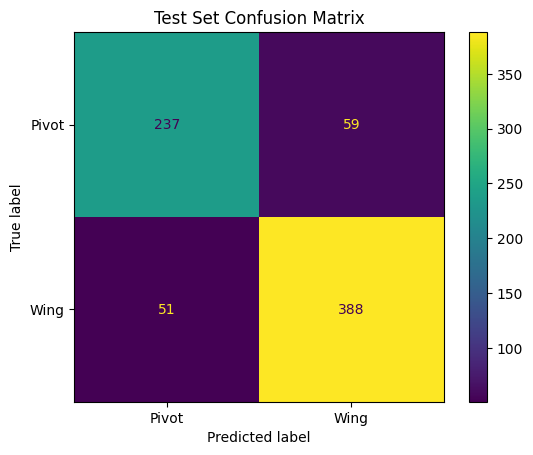

ROC-AUC Score:    0.9172


In [245]:
final_pred_advanced = rs_best_advanced.best_estimator_.predict(X_advanced_test)
print(f"Final Model F1:   {f1_score(y_test, final_pred_advanced):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, final_pred_advanced, target_names=['Pivot', 'Wing']))

ConfusionMatrixDisplay.from_predictions(y_test, final_pred_advanced, display_labels=['Pivot', 'Wing'])
plt.title('Test Set Confusion Matrix')
plt.show()

if hasattr(rs_best_advanced.best_estimator_, 'predict_proba'):
    proba = rs_best_advanced.best_estimator_.predict_proba(X_advanced_test)[:, 1]
    print(f"ROC-AUC Score:    {roc_auc_score(y_test, proba):.4f}")

Final Model F1:   0.8718

Classification Report:
              precision    recall  f1-score   support

       Pivot       0.83      0.77      0.80       296
        Wing       0.85      0.89      0.87       439

    accuracy                           0.84       735
   macro avg       0.84      0.83      0.84       735
weighted avg       0.84      0.84      0.84       735



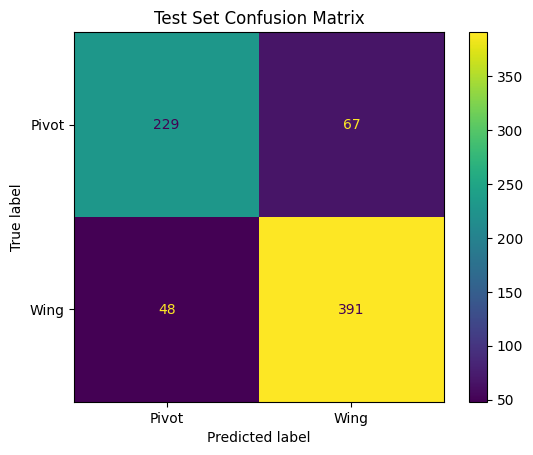

ROC-AUC Score:    0.9147


In [246]:
final_pred = rs_best.best_estimator_.predict(X_test)
print(f"Final Model F1:   {f1_score(y_test, final_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, final_pred, target_names=['Pivot', 'Wing']))

ConfusionMatrixDisplay.from_predictions(y_test, final_pred, display_labels=['Pivot', 'Wing'])
plt.title('Test Set Confusion Matrix')
plt.show()

if hasattr(rs_best.best_estimator_, 'predict_proba'):
    proba = rs_best.best_estimator_.predict_proba(X_test)[:, 1]
    print(f"ROC-AUC Score:    {roc_auc_score(y_test, proba):.4f}")

In [247]:
cls_advanced = rs_best_advanced.best_estimator_
cls = rs_best.best_estimator_

In [248]:
train_sizes_advanced, train_scores_advanced, test_scores_advanced = learning_curve(cls_advanced,
                                                       X=X_advanced_train,
                                                       y=y_train,
                                                       train_sizes= [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                                       cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                                                       n_jobs = -1,
                                                       scoring = 'f1',
                                                       shuffle=True,
                                                       random_state=RANDOM_STATE)

In [249]:
train_sizes, train_scores, test_scores = learning_curve(cls,
                                                       X=X_train,
                                                       y=y_train,
                                                       train_sizes= [0.01, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
                                                       cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
                                                       n_jobs = -1,
                                                       scoring = 'f1',
                                                       shuffle=True,
                                                       random_state=RANDOM_STATE)

As the graph show, the model learn well and quickly also with very few data (the validation score is really close to the training score, a good sign for the bias/variance trade-off). Generally this is really good and in this case it could be that the model is that good because the dataset is not really big and the problem is relatively simple.

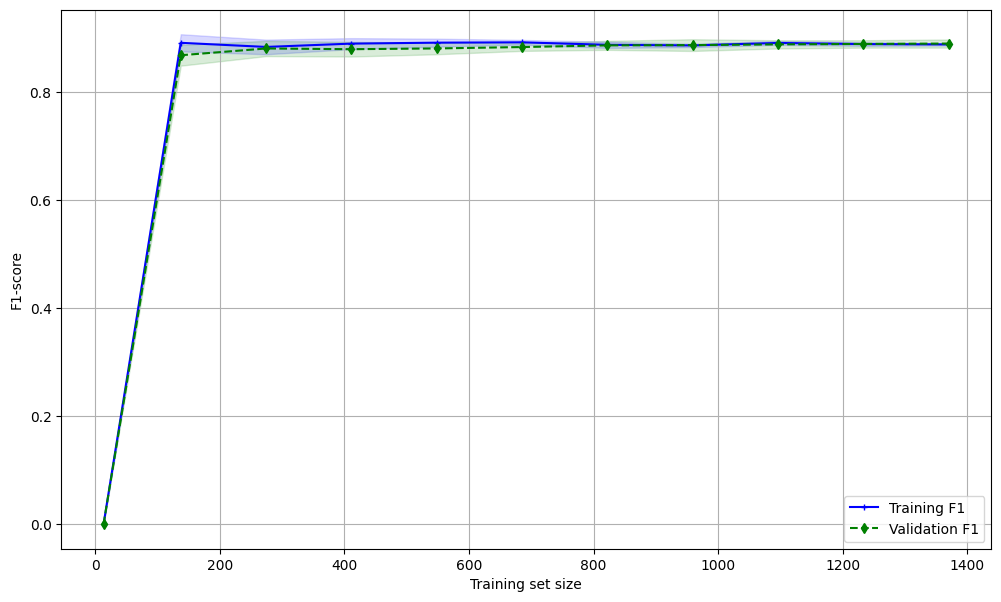

In [250]:
train_mean = np.mean(train_scores_advanced, axis=1)
train_std = np.std(train_scores_advanced, axis=1)
test_mean = np.mean(test_scores_advanced, axis=1)
test_std = np.std(test_scores_advanced, axis=1)

fig=plt.figure(figsize=(12,7))
ax = fig.add_subplot()

ax.plot(train_sizes_advanced, train_mean,
         color='blue', marker='+',
         markersize=5, label='Training F1')

ax.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='d', markersize=5,
         label='Validation F1')

ax.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Training set size')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')

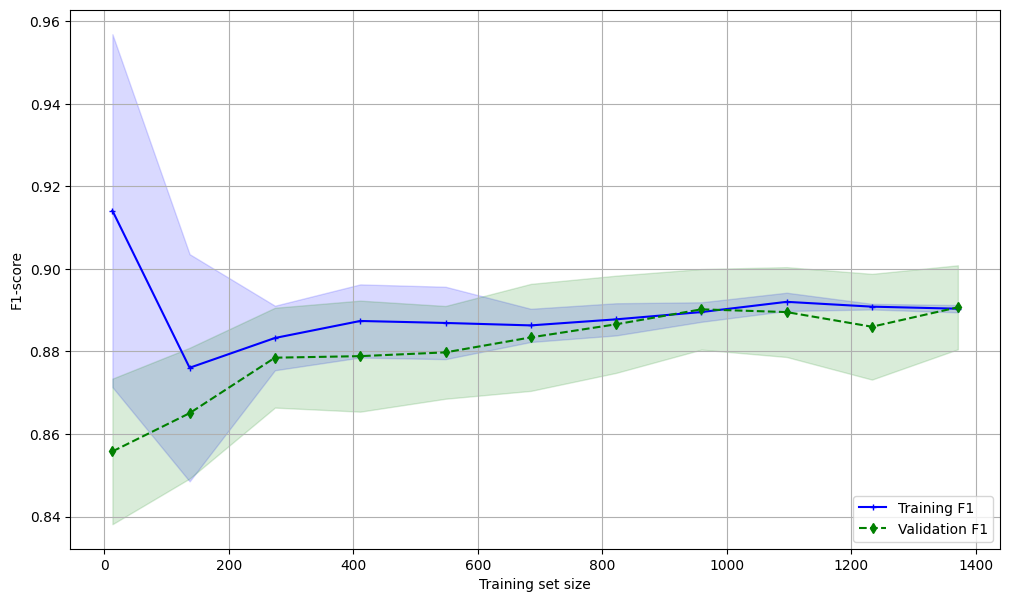

In [251]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig=plt.figure(figsize=(12,7))
ax = fig.add_subplot()

ax.plot(train_sizes, train_mean,
         color='blue', marker='+',
         markersize=5, label='Training F1')

ax.fill_between(train_sizes,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(train_sizes, test_mean,
         color='green', linestyle='--',
         marker='d', markersize=5,
         label='Validation F1')

ax.fill_between(train_sizes,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Training set size')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')

In [252]:
range_C = [0.0001, 0.001,0.01,0.1,1,10,100]
train_scores_advanced, test_scores_advanced = validation_curve(cls_advanced,
        X=X_advanced_train,
        y=y_train,
        param_range=range_C,
        param_name='classifier__C',
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1,
        scoring='f1'
)

In [253]:
range_C = [0.0001, 0.001,0.01,0.1,1,10,100]
train_scores, test_scores = validation_curve(cls,
        X=X_train,
        y=y_train,
        param_range=range_C,
        param_name='classifier__C',
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
        n_jobs=-1,
        scoring='f1'
)

Instead, here the validation curve shows that the model is not really sensitive to the variation of the hyperparameter C after a certain threshold (around 10^-2). This is also a good sign because it's easy to find the optimal value for C (in this case it could be around 10) and it's not needed to use a more complex model.

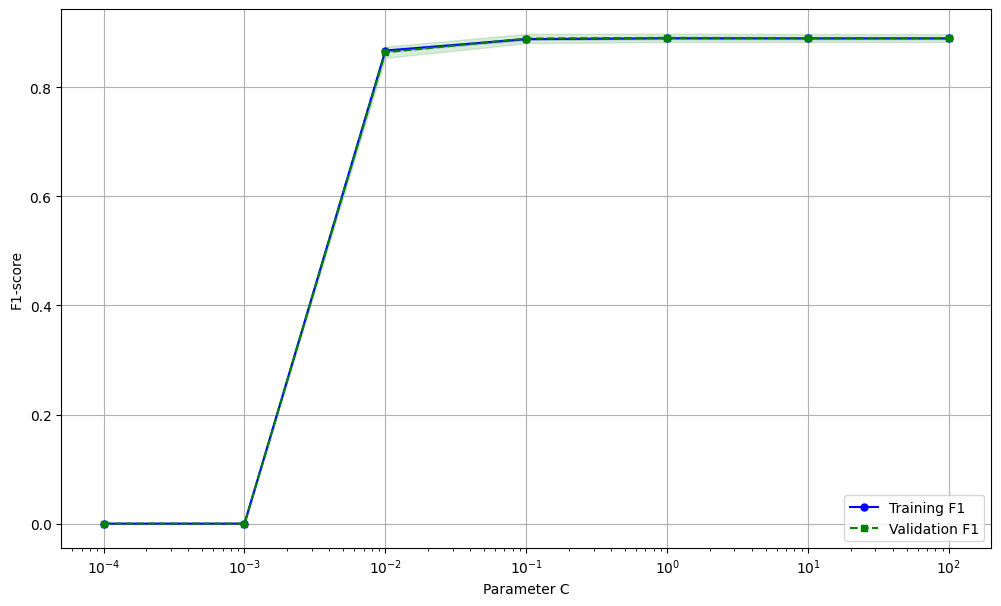

In [254]:
train_mean = np.mean(train_scores_advanced, axis=1)
train_std = np.std(train_scores_advanced, axis=1)
test_mean = np.mean(test_scores_advanced, axis=1)
test_std = np.std(test_scores_advanced, axis=1)

fig=plt.figure(figsize=(12,7))
ax = fig.add_subplot()
ax.plot(range_C, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training F1')

ax.fill_between(range_C,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(range_C, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation F1')

ax.fill_between(range_C,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Parameter C')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')
ax.set_xscale('log')

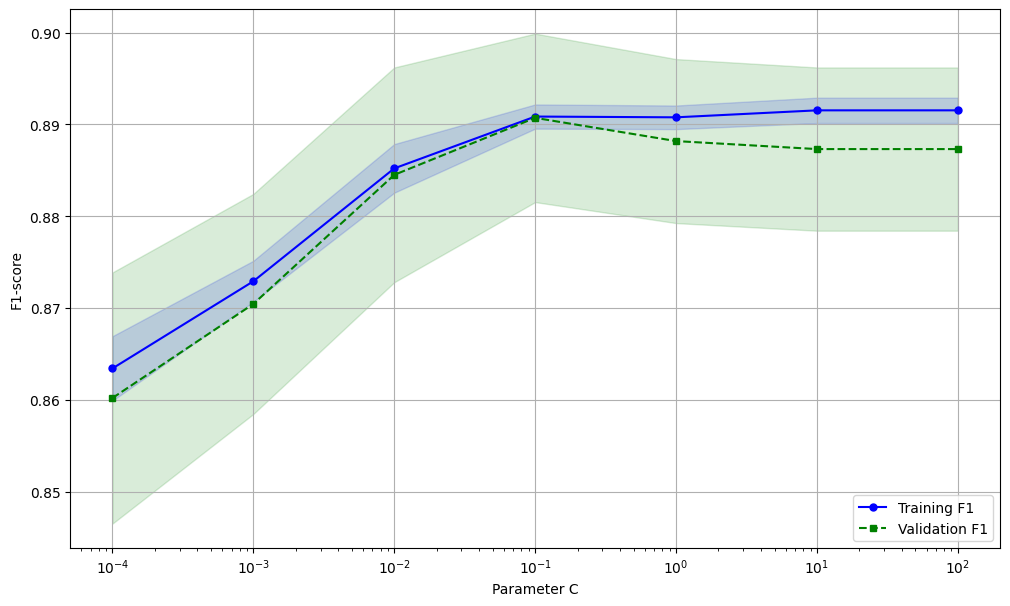

In [255]:
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig=plt.figure(figsize=(12,7))
ax = fig.add_subplot()
ax.plot(range_C, train_mean,
         color='blue', marker='o',
         markersize=5, label='Training F1')

ax.fill_between(range_C,
                 train_mean + train_std,
                 train_mean - train_std,
                 alpha=0.15, color='blue')

ax.plot(range_C, test_mean,
         color='green', linestyle='--',
         marker='s', markersize=5,
         label='Validation F1')

ax.fill_between(range_C,
                 test_mean + test_std,
                 test_mean - test_std,
                 alpha=0.15, color='green')

ax.grid()
ax.set_xlabel('Parameter C')
ax.set_ylabel('F1-score')
ax.legend(loc='lower right')
ax.set_xscale('log')

## EXPLAINABLE AI (XAI) & MODEL INTERPRETABILITY

In competitive sports analytics, establishing interpretability is essential for coaches and performance analysts. We employ a multi-level explainability framework:
1. **Global Game-Theoretic Interpretability (SHAP Beeswarm & Importance)**: Uncovering the direction and magnitude of each feature's contribution across the dataset.
2. **Permutation Feature Importance**: Evaluating out-of-sample generalization impact on the test set.
3. **Partial Dependence Plots (PDP)**: Analyzing the marginal effect of key continuous metrics on role probability.
4. **Local Interpretability (SHAP Waterfall Plots)**: Providing actionable, player-level scouting breakdowns for representative profiles.


### 1. Global Feature Attribution (SHAP Beeswarm & Summary Plots)

We compute exact Shapley values using `shap.LinearExplainer` on the standardized feature representation.

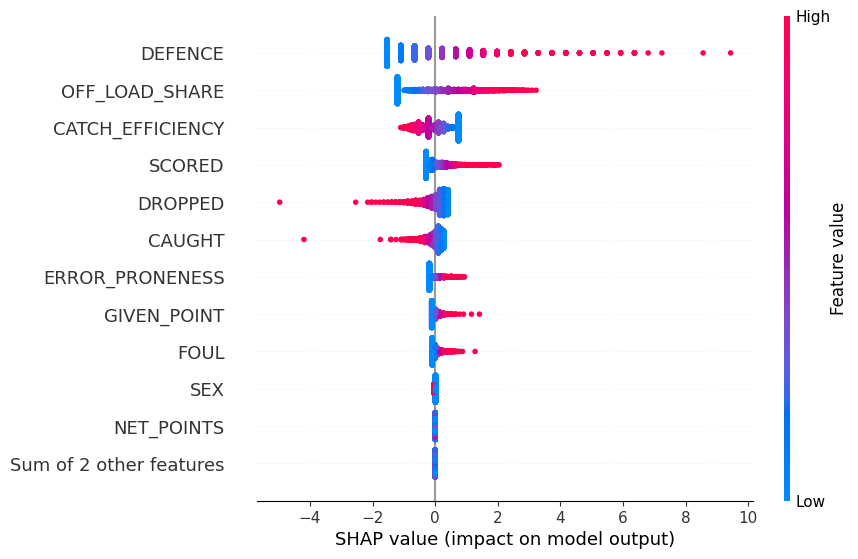

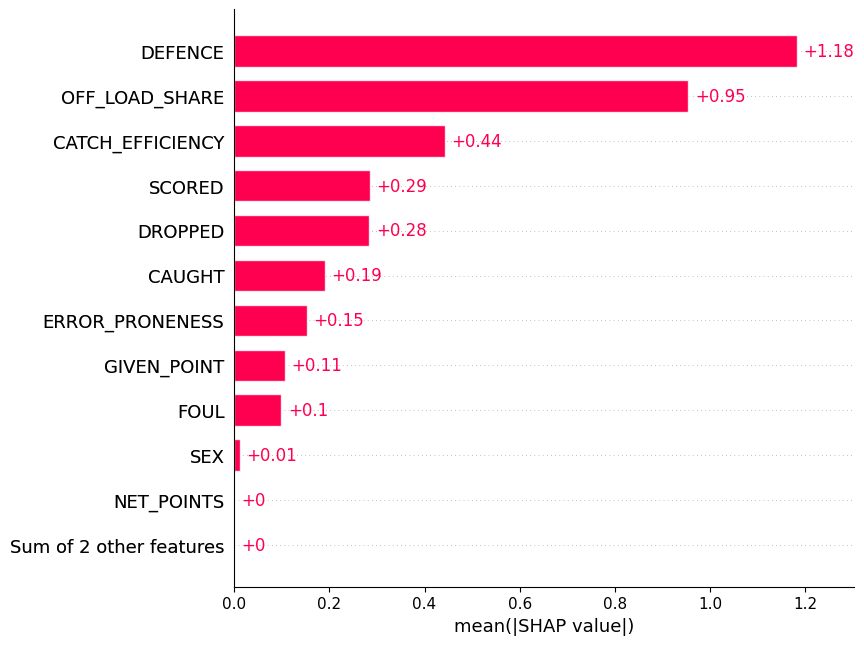

In [256]:
X_trans_advanced = cls_advanced.named_steps['trans'].transform(X_advanced)
classifier_advanced = cls_advanced.named_steps['classifier']

explainer_advanced = shap.LinearExplainer(classifier_advanced, X_trans_advanced, feature_names=X_trans_advanced.columns)
shap_values_advanced = explainer_advanced(X_trans_advanced)

# SHAP Beeswarm Plot (Feature impact distribution for Wing classification)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values_advanced, max_display=12, show=True)

# SHAP Mean Absolute Importance Bar Plot
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_advanced, max_display=12, show=True)

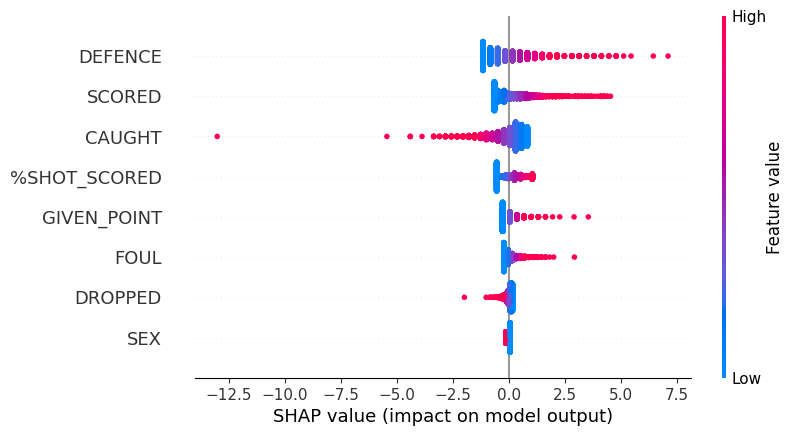

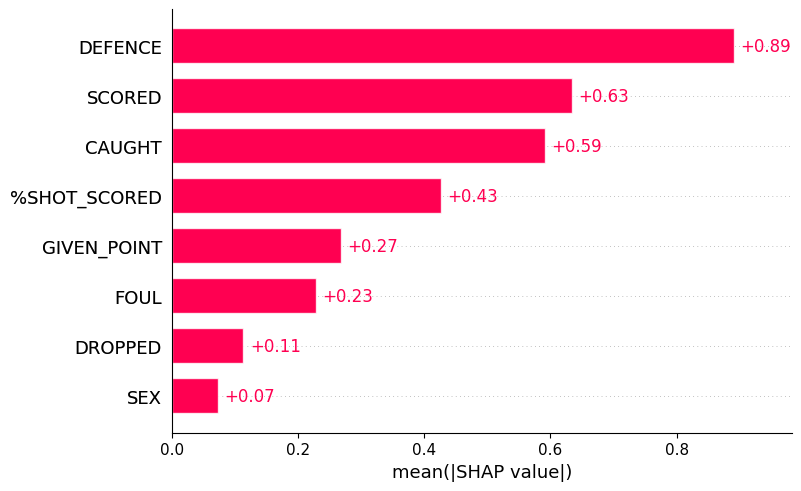

In [257]:
X_trans = cls.named_steps['trans'].transform(X)
classifier = cls.named_steps['classifier']

explainer = shap.LinearExplainer(classifier, X_trans, feature_names=X_trans.columns)
shap_values = explainer(X_trans)

# SHAP Beeswarm Plot (Feature impact distribution for Wing classification)
plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_values, max_display=12, show=True)

# SHAP Mean Absolute Importance Bar Plot
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values, max_display=12, show=True)

### 2. Model-Agnostic Permutation Importance (Test Set)

We evaluate how shuffling each feature on the unseen test set degrades the model's F1-score.

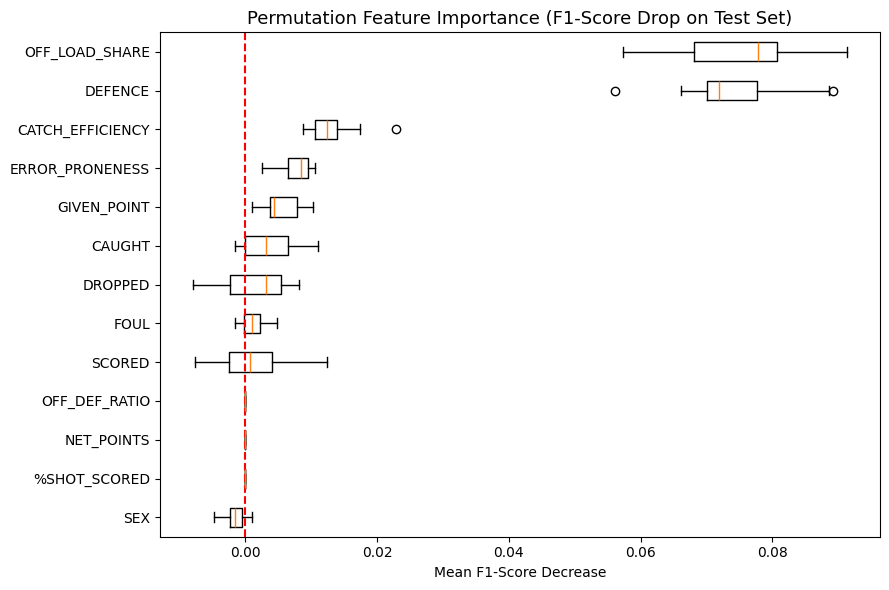

In [258]:
X_test_trans_advanced = cls_advanced.named_steps['trans'].transform(X_advanced_test)
perm_res_advanced = permutation_importance(
    classifier_advanced, X_test_trans_advanced, y_test,
    scoring='f1', n_repeats=10, random_state=RANDOM_STATE
)

importances_advanced = perm_res_advanced.importances_mean
importances_advanced = np.clip(importances_advanced, a_min=0, a_max=None)
sorted_idx_advanced = perm_res_advanced.importances_mean.argsort()

plt.figure(figsize=(9, 6))
plt.boxplot(perm_res_advanced.importances[sorted_idx_advanced].T, vert=False, tick_labels=X_test_trans_advanced.columns[sorted_idx_advanced])
plt.axvline(x=0, color="red", linestyle="--")
plt.title("Permutation Feature Importance (F1-Score Drop on Test Set)", fontsize=13)
plt.xlabel("Mean F1-Score Decrease")
plt.tight_layout()
plt.show()

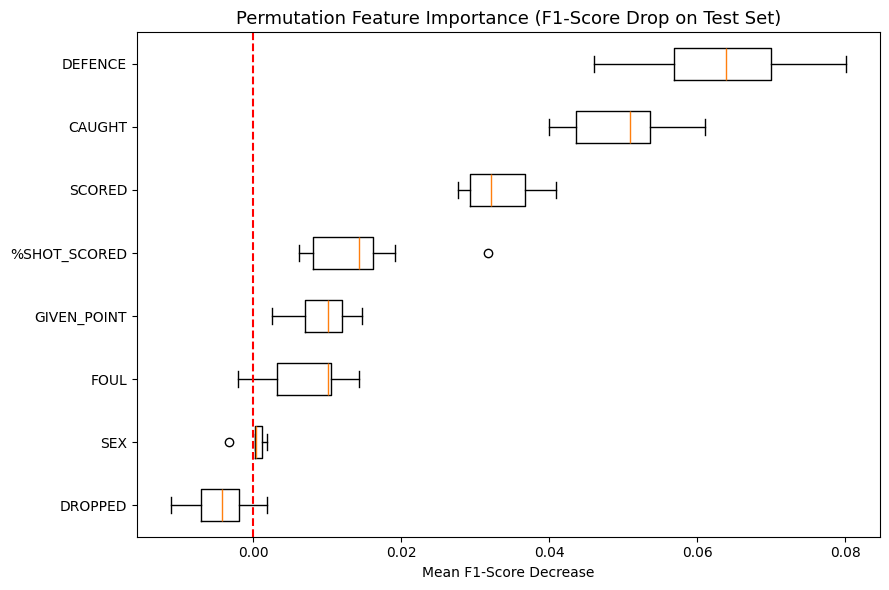

In [259]:
X_test_trans = cls.named_steps['trans'].transform(X_test)
perm_res = permutation_importance(
    classifier, X_test_trans, y_test,
    scoring='f1', n_repeats=10, random_state=RANDOM_STATE
)

importances = perm_res.importances_mean
importances = np.clip(importances, a_min=0, a_max=None)
sorted_idx = perm_res.importances_mean.argsort()

plt.figure(figsize=(9, 6))
plt.boxplot(perm_res.importances[sorted_idx].T, vert=False, tick_labels=X_test_trans.columns[sorted_idx])
plt.axvline(x=0, color="red", linestyle="--")
plt.title("Permutation Feature Importance (F1-Score Drop on Test Set)", fontsize=13)
plt.xlabel("Mean F1-Score Decrease")
plt.tight_layout()
plt.show()

### 3. Partial Dependence Plots (PDP)

We inspect the non-linear marginal transition curves for the top discriminative features.

In [260]:
top_features_advanced = []
count = len(X_test_trans_advanced.columns[sorted_idx_advanced])
for column in X_test_trans_advanced.columns[sorted_idx_advanced]:
  if column != "SEX" and count<6:
    top_features_advanced.append(str(column))
  count -= 1

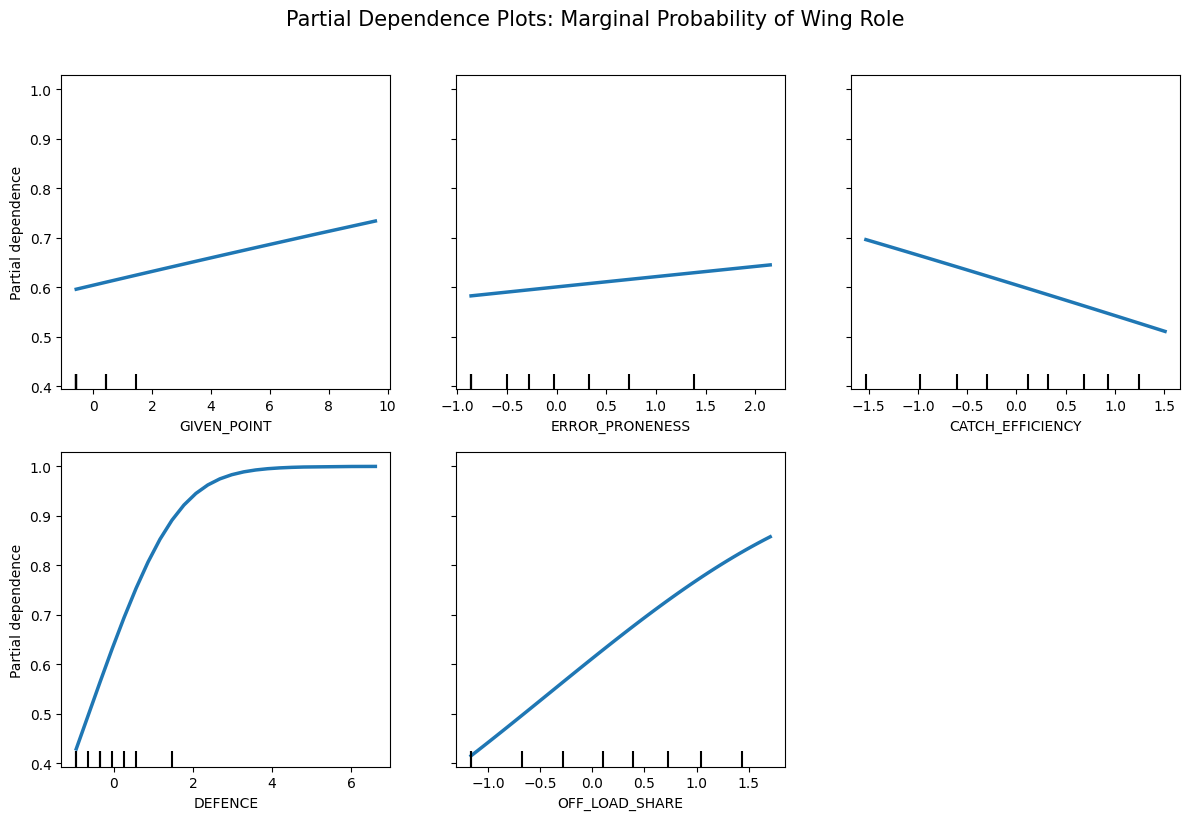

In [261]:
fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    classifier_advanced, X_test_trans_advanced,
    features=top_features_advanced,
    ax=ax,
    grid_resolution=50,
    line_kw={"color": "#1f77b4", "linewidth": 2.5}
)
plt.suptitle("Partial Dependence Plots: Marginal Probability of Wing Role", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [262]:
top_features = []
count = len(X_test_trans.columns[sorted_idx])
for column in X_test_trans.columns[sorted_idx]:
  if column != "SEX" and count<6:
    top_features.append(str(column))
  count -= 1

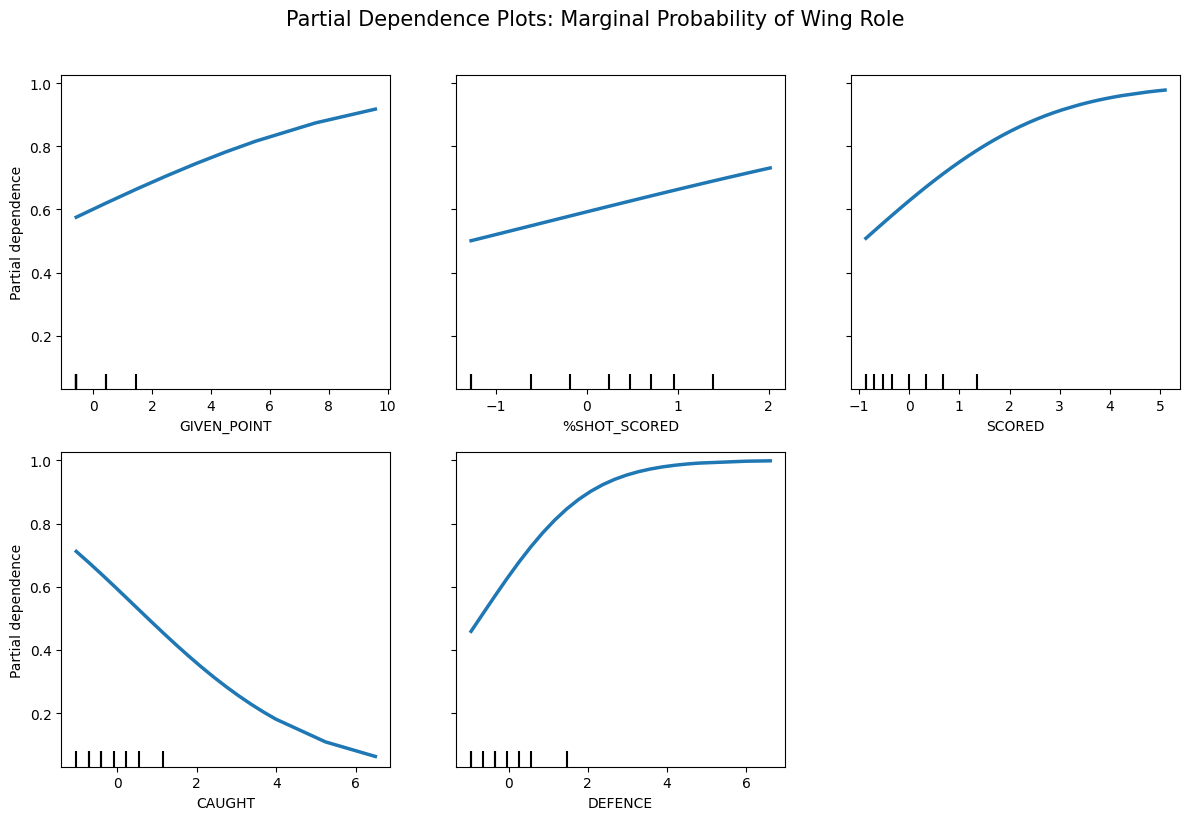

In [263]:
fig, ax = plt.subplots(figsize=(12, 8))
PartialDependenceDisplay.from_estimator(
    classifier, X_test_trans,
    features=top_features,
    ax=ax,
    grid_resolution=50,
    line_kw={"color": "#1f77b4", "linewidth": 2.5}
)
plt.suptitle("Partial Dependence Plots: Marginal Probability of Wing Role", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

### 4. Local Interpretability: Scouting Case Studies (SHAP Waterfall Plots)

Individual waterfall breakdowns explain why specific player performances were classified as Wing or Pivot.

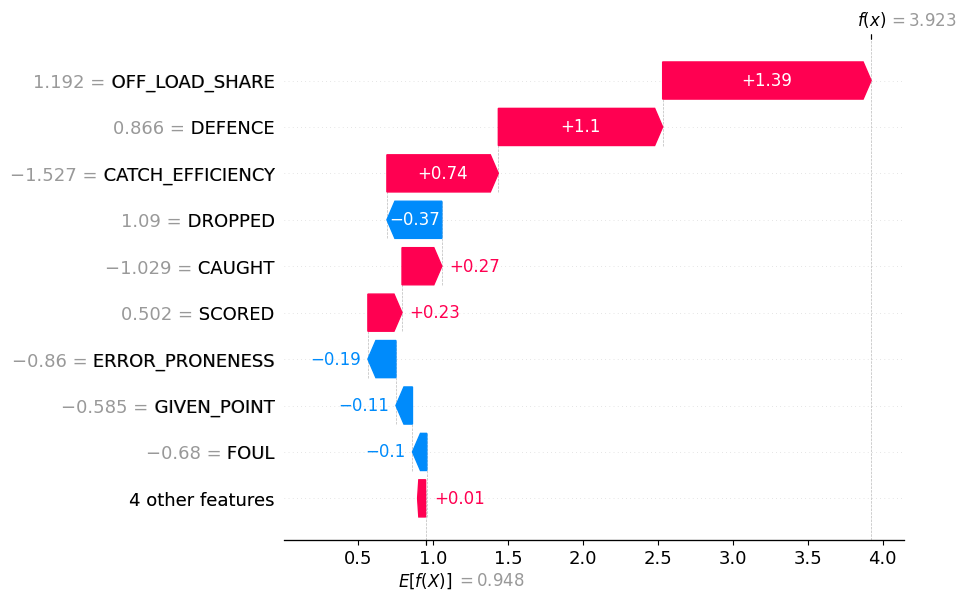

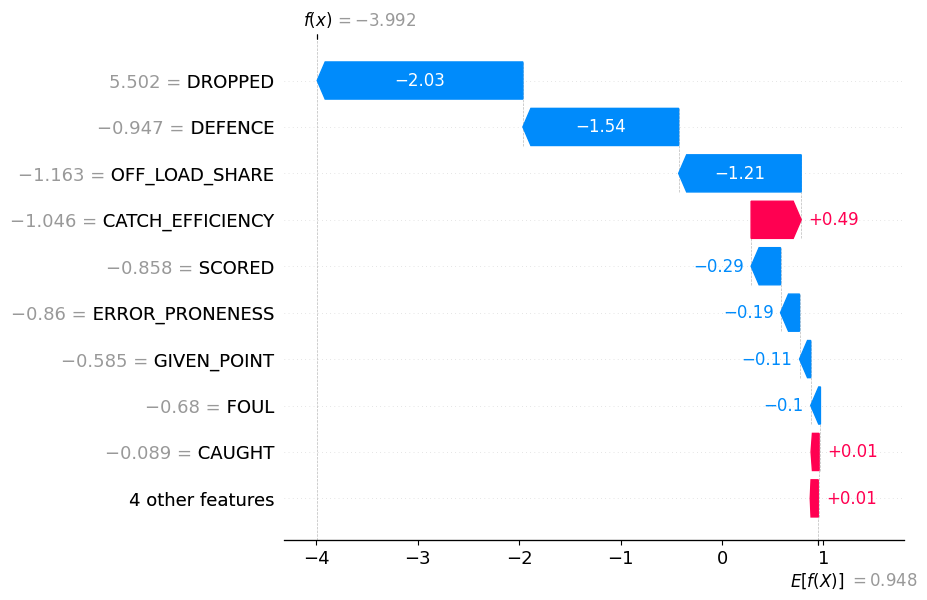

In [264]:
# Case 1: Prototypical Wing Profile (High offensive load & ratio)
wing_candidates_advanced = np.where((y == 1) & (cls_advanced.predict_proba(X_advanced)[:, 1] > 0.90))[0]
if len(wing_candidates_advanced) > 0:
    shap.plots.waterfall(shap_values_advanced[wing_candidates_advanced[0]], show=True)

# Case 2: Prototypical Pivot Profile (Defensive anchor & catch efficiency)
pivot_candidates_advanced = np.where((y == 0) & (cls_advanced.predict_proba(X_advanced)[:, 1] < 0.10))[0]
if len(pivot_candidates_advanced) > 0:
    shap.plots.waterfall(shap_values_advanced[pivot_candidates_advanced[0]], show=True)

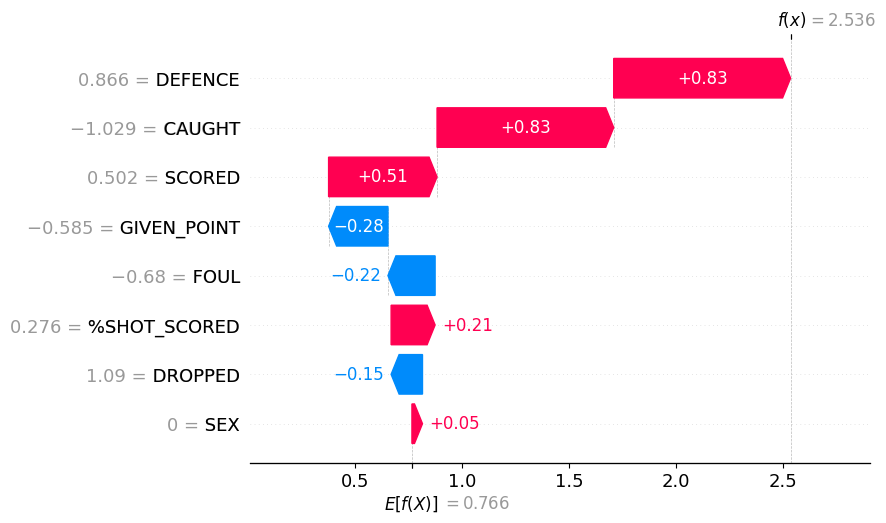

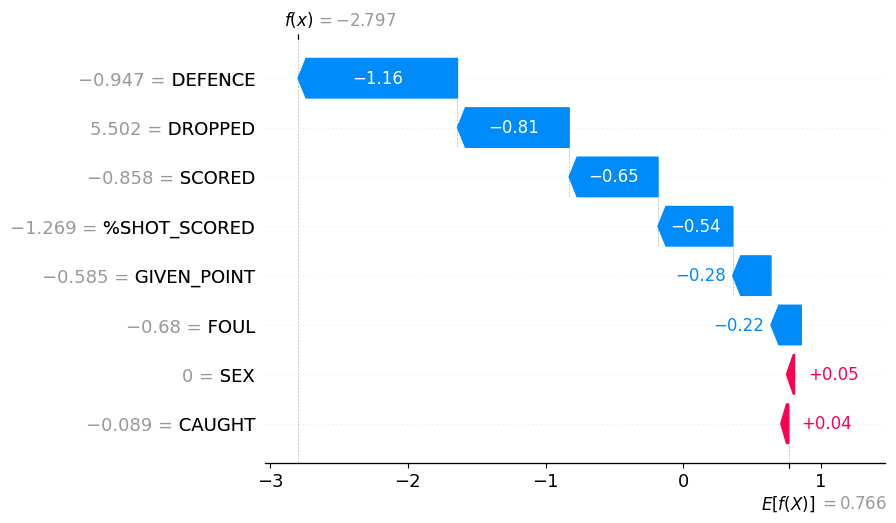

In [265]:
# Case 1: Prototypical Wing Profile (High offensive load & ratio)
wing_candidates = np.where((y == 1) & (cls.predict_proba(X)[:, 1] > 0.90))[0]
if len(wing_candidates) > 0:
    shap.plots.waterfall(shap_values[wing_candidates[0]], show=True)

# Case 2: Prototypical Pivot Profile (Defensive anchor & catch efficiency)
pivot_candidates = np.where((y == 0) & (cls.predict_proba(X)[:, 1] < 0.10))[0]
if len(pivot_candidates) > 0:
    shap.plots.waterfall(shap_values[pivot_candidates[0]], show=True)


##CLUSTERING

As I said at the start of this project only two classes is really just an approximation so I decided to try to see if the data can be clustered in a more meaningful way. Moreover, the datas are gathered from different competitions: tchoukball in Europe is prevalently a mixed sport but some international competition are divided in Men and Women categories. In this section, I will try to see differences also between this three categories

For all the test I use a soft probabilistic algorithm (from Gaussian Mixture Models) in order to capture hybrid player archetypes on the standardized feature space.

In [266]:
def plot_clustering(X, labels, centroids=[]):
    fig, ax = plt.subplots(figsize=(8, 6))
    X_arr = np.asarray(X)
    labels = np.asarray(labels)
    unique_labels = np.unique(labels)

    for label in unique_labels:
        mask = (labels == label)
        ax.scatter(X_arr[mask, 0], X_arr[mask, 1], label=f'Cluster {label}', alpha=0.7, s=30)

    if len(centroids) > 0:
        centroids_arr = np.asarray(centroids)
        ax.scatter(centroids_arr[:, 0], centroids_arr[:, 1],
            marker='*',
            s=200,
            c='red',
            edgecolor='black',
            label='Centroids'
        )
    ax.set_title('GMM clustering on 2D Embedding', fontsize=14)
    ax.legend()
    plt.tight_layout()
    plt.show()

def plot_archetype_radar(df_means):
    df_norm = (df_means - df_means.min()) / (df_means.max() - df_means.min() + 1e-6)

    categories = list(df_norm.columns)
    N = len(categories)
    angles = [n / float(N) * 2 * np.pi for n in range(N)]
    angles += angles[:1]

    fig, axes = plt.subplots(1, len(df_norm), figsize=(20, 5), subplot_kw=dict(polar=True))

    for i, (idx, row) in enumerate(df_norm.iterrows()):
        values = row.values.flatten().tolist()
        values += values[:1]

        ax = axes[i] if len(df_norm) > 1 else axes
        ax.plot(angles, values, linewidth=2, linestyle='solid')
        ax.fill(angles, values, alpha=0.3)
        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(categories, fontsize=9)
        ax.set_title(f"archetype n{i}", fontsize=13, weight='bold', pad=15)

    plt.tight_layout()
    plt.show()

In [ ]:
weights_advanced = importances_advanced / importances_advanced.mean()

X_clustering_df_advanced = cls_advanced.named_steps['trans'].transform(X_advanced)
X_clustering_scaled_advanced = np.asarray(X_clustering_df_advanced)
X_clustering_weighted_advanced = X_clustering_scaled_advanced * np.sqrt(weights_advanced)

In [ ]:
X_tsne_advanced = TSNE(
    n_components=2,
    init='pca',
    learning_rate='auto',
    max_iter=500,
    random_state=RANDOM_STATE
).fit_transform(X_clustering_weighted_advanced)

X_tsne_advanced

,tsne0,tsne1
0,-25.332245,15.016819
1,18.343904,-0.888119
2,23.519033,0.064621
3,28.150681,1.237130
4,-12.910347,-19.566740
...,...,...
2444,7.217218,-20.323889
2445,1.387311,0.237646
2446,-28.341307,-15.286116
2447,-5.647189,-7.748347


best K (ICL): 13


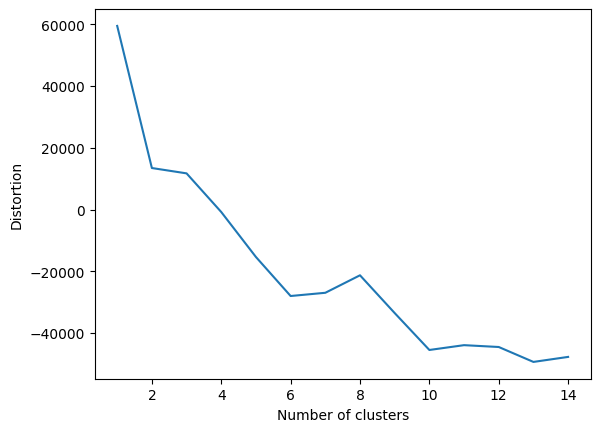

In [ ]:
icl_scores_advanced = []

for i in np.arange(1, 15):
    gmm_loop = GaussianMixture(n_components=i,
                          covariance_type='full',
                          random_state=RANDOM_STATE)
    gmm_loop.fit(X_clustering_scaled_advanced)
    bic = gmm_loop.bic(X_clustering_scaled_advanced)
    probs = gmm_loop.predict_proba(X_clustering_scaled_advanced)
    probs_clipped = np.clip(probs, 1e-10, 1)
    entropy = -np.sum(probs_clipped * np.log(probs_clipped))
    icl = bic + 2 * entropy
    icl_scores_advanced.append(icl)

best_k_icl_advanced = list(range(1, 15))[np.argmin(icl_scores_advanced)]
print(f"best K (ICL): {best_k_icl_advanced}")

plt.plot(np.arange(1, 15), icl_scores_advanced)
plt.xlabel('Number of clusters')
plt.ylabel('ICL')
plt.show()

In [ ]:
weights = importances / importances.mean()

X_clustering_df = cls.named_steps['trans'].transform(X)
X_clustering_scaled = np.asarray(X_clustering_df)
X_clustering_weighted = X_clustering_scaled * np.sqrt(weights)

In [ ]:
X_tsne = TSNE(
    n_components=2,
    init='pca',
    learning_rate='auto',
    max_iter=500,
    random_state=RANDOM_STATE
).fit_transform(X_clustering_weighted)

X_tsne

,tsne0,tsne1
0,-32.377728,5.427598
1,8.222684,19.922333
2,17.295710,-13.227807
3,18.470385,3.012506
4,-12.613093,1.609871
...,...,...
2444,0.414996,3.856825
2445,1.044286,-15.511868
2446,-29.333427,13.617941
2447,-15.360223,0.074974


best K (ICL): 9


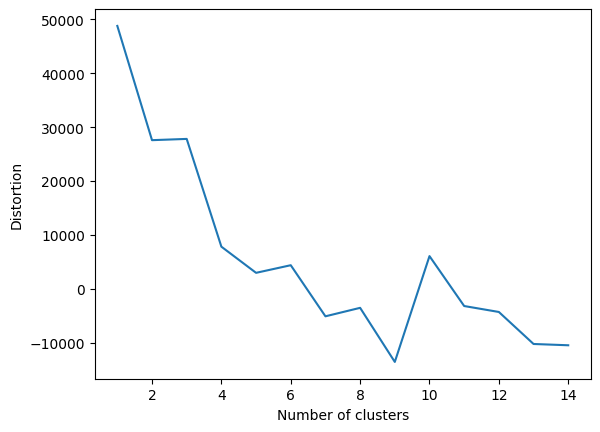

In [ ]:
icl_scores = []

for i in np.arange(1, 15):
    gmm_loop = GaussianMixture(n_components=i,
                          covariance_type='full',
                          random_state=RANDOM_STATE)
    gmm_loop.fit(X_clustering_scaled)
    bic = gmm_loop.bic(X_clustering_scaled)
    probs = gmm_loop.predict_proba(X_clustering_scaled)
    probs_clipped = np.clip(probs, 1e-10, 1)
    entropy = -np.sum(probs_clipped * np.log(probs_clipped))
    icl = bic + 2 * entropy
    icl_scores.append(icl)

best_k_icl = list(range(1, 15))[np.argmin(icl_scores)]
print(f"best K (ICL): {best_k_icl}")

plt.plot(np.arange(1, 15), icl_scores)
plt.xlabel('Number of clusters')
plt.ylabel('ICL')
plt.show()

###MIXED

Even if the best number of components is 12 (or maybe more with more iteration), in order to mantain some graphs that are pretty to visualize I opted for the local minimum at 4 components

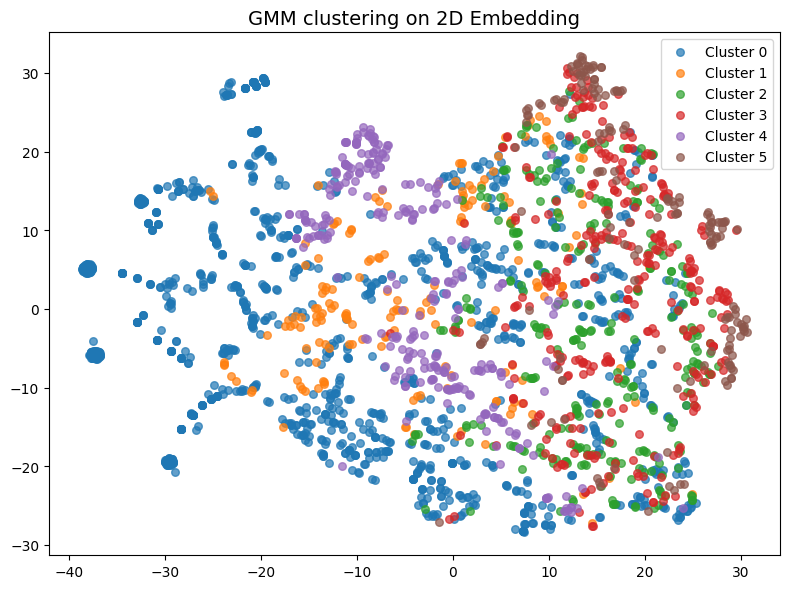

In [273]:
gmm_advanced = GaussianMixture(n_components=6, covariance_type='full', random_state=RANDOM_STATE)
gmm_labels_advanced = gmm_advanced.fit_predict(X_clustering_weighted_advanced)
plot_clustering(X_tsne_advanced, gmm_labels_advanced, centroids=[])

In [274]:
archetype_labels_advanced = gmm_labels_advanced
archetype_summary_advanced = X_advanced.copy()
archetype_summary_advanced['ARCHETYPE'] = archetype_labels_advanced

advanced_stats_to_show = [
    'SCORED', 'DEFENCE', 'CAUGHT', 'DROPPED',
    '%SHOT_SCORED', 'OFF_DEF_RATIO', 'CATCH_EFFICIENCY', 'NET_POINTS'
]

mean_statlines_advanced = archetype_summary_advanced.groupby('ARCHETYPE')[advanced_stats_to_show].mean().round(2)
mean_statlines_advanced['PLAYERS_COUNT'] = archetype_summary_advanced['ARCHETYPE'].value_counts()
mean_statlines_advanced

,SCORED,DEFENCE,CAUGHT,DROPPED,%SHOT_SCORED,OFF_DEF_RATIO,CATCH_EFFICIENCY,NET_POINTS,PLAYERS_COUNT
ARCHETYPE,,,,,,,,,
0,2.10,1.71,3.36,2.38,44.52,0.87,0.44,2.04,1194
1,3.14,3.50,6.19,5.27,28.58,1.20,0.46,2.13,179
2,7.62,4.25,2.12,2.12,56.15,3.16,0.40,6.50,307
3,11.42,5.84,3.37,3.74,55.64,3.73,0.43,10.07,317
4,1.71,1.66,0.96,2.61,29.66,1.11,0.18,0.46,287
5,18.30,8.53,5.75,3.16,57.23,4.03,0.56,16.56,165


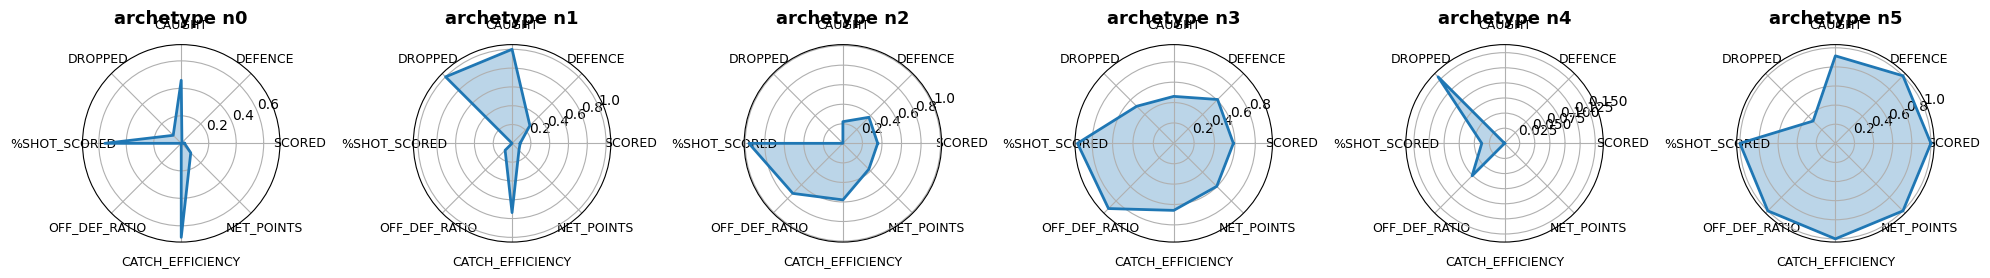

In [275]:
plot_archetype_radar(mean_statlines_advanced[advanced_stats_to_show])

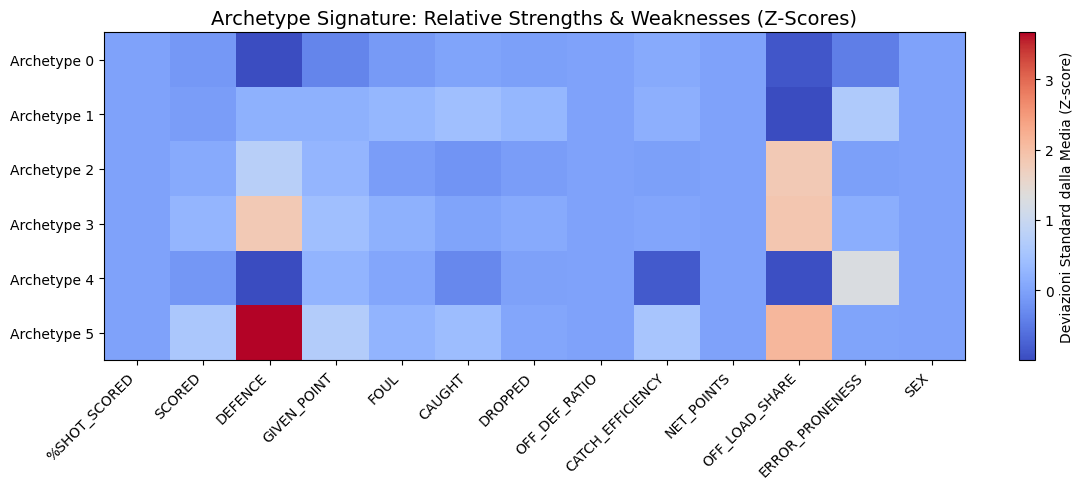

In [276]:
# Calcolo Z-Score medio per archetipo
z_scores_advanced = pd.DataFrame(X_clustering_weighted_advanced, columns=X_trans_advanced.columns)
z_scores_advanced['ARCHETYPE'] = archetype_labels_advanced
archetype_z_advanced = z_scores_advanced.groupby('ARCHETYPE').mean()

plt.figure(figsize=(12, 5))
plt.imshow(archetype_z_advanced.values, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Deviazioni Standard dalla Media (Z-score)')
plt.xticks(range(len(archetype_z_advanced.columns)), archetype_z_advanced.columns, rotation=45, ha='right')
plt.yticks(range(len(archetype_z_advanced)), [f"Archetype {i}" for i in range(len(archetype_z_advanced))])
plt.title("Archetype Signature: Relative Strengths & Weaknesses (Z-Scores)", fontsize=14)
plt.tight_layout()
plt.show()

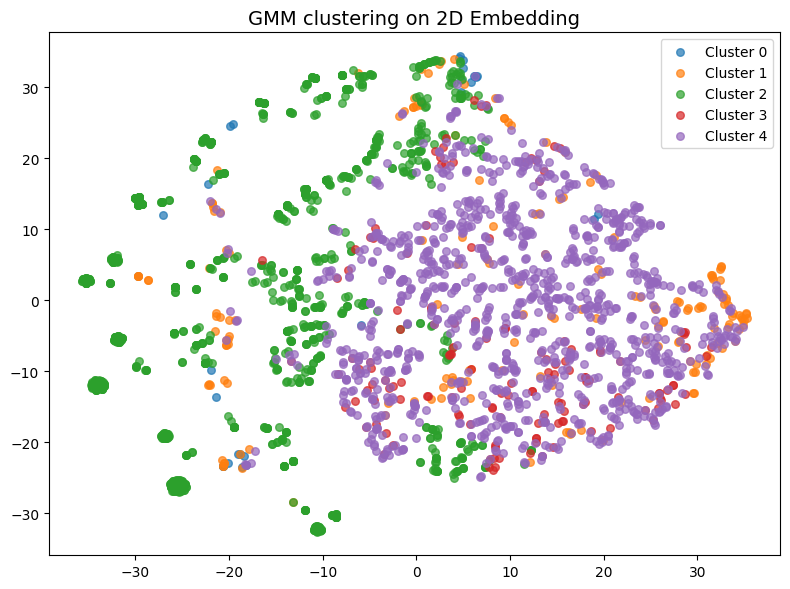

In [277]:
gmm = GaussianMixture(n_components=5, covariance_type='full', random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(X_clustering_weighted)
plot_clustering(X_tsne, gmm_labels, centroids=[])

In [278]:
archetype_labels = gmm_labels
archetype_summary = X.copy()
archetype_summary['ARCHETYPE'] = archetype_labels

stats_to_show = [
    'SCORED', 'DEFENCE', 'CAUGHT', 'DROPPED', '%SHOT_SCORED'
]

mean_statlines = archetype_summary.groupby('ARCHETYPE')[stats_to_show].mean().round(2)
mean_statlines['PLAYERS_COUNT'] = archetype_summary['ARCHETYPE'].value_counts()
mean_statlines

,SCORED,DEFENCE,CAUGHT,DROPPED,%SHOT_SCORED,PLAYERS_COUNT
ARCHETYPE,,,,,,
0,4.96,1.55,8.64,2.44,28.86,30
1,5.38,6.31,4.91,3.48,23.19,177
2,0.89,0.87,3.48,2.39,38.36,999
3,4.43,4.62,2.86,3.33,42.08,145
4,9.10,4.60,2.86,3.04,54.21,1098


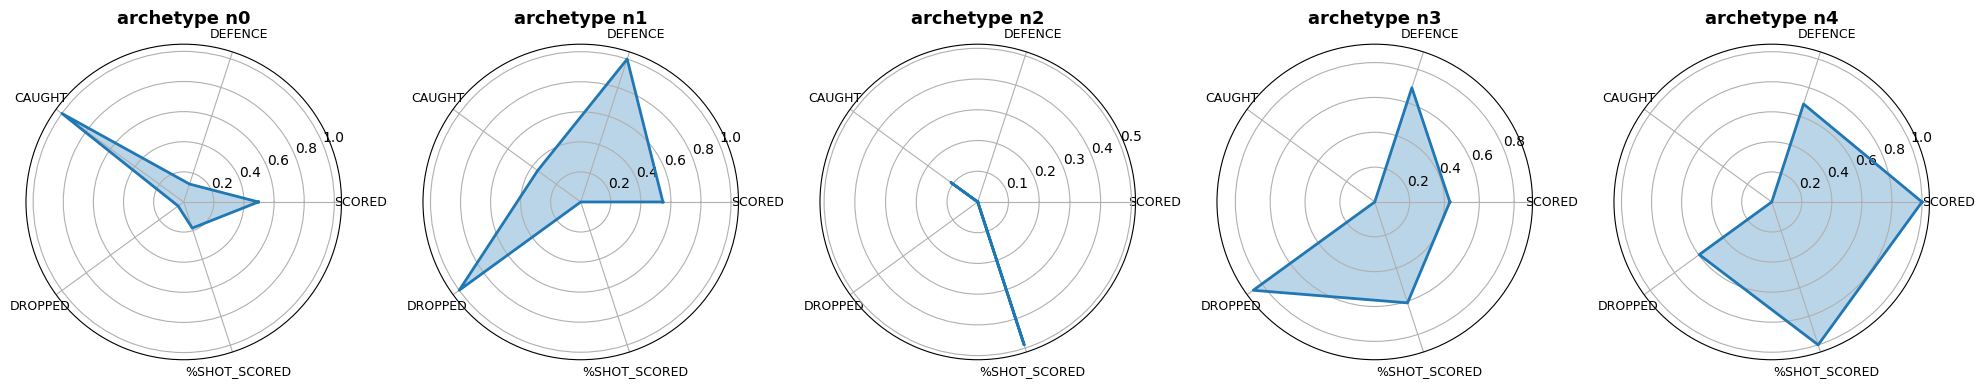

In [279]:
plot_archetype_radar(mean_statlines[stats_to_show])

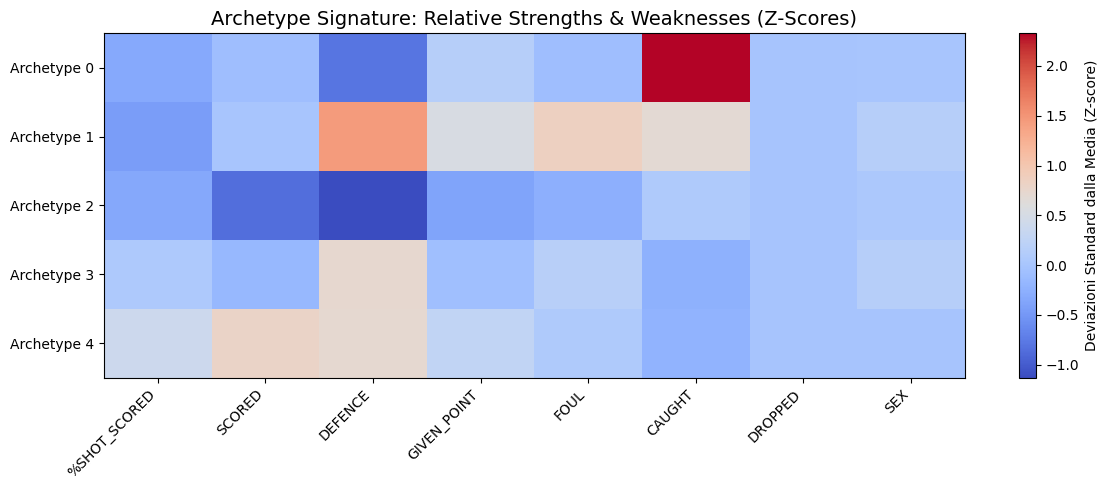

In [280]:
# Calcolo Z-Score medio per archetipo
z_scores = pd.DataFrame(X_clustering_weighted, columns=X_trans.columns)
z_scores['ARCHETYPE'] = archetype_labels
archetype_z = z_scores.groupby('ARCHETYPE').mean()

plt.figure(figsize=(12, 5))
plt.imshow(archetype_z.values, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Deviazioni Standard dalla Media (Z-score)')
plt.xticks(range(len(archetype_z.columns)), archetype_z.columns, rotation=45, ha='right')
plt.yticks(range(len(archetype_z)), [f"Archetype {i}" for i in range(len(archetype_z))])
plt.title("Archetype Signature: Relative Strengths & Weaknesses (Z-Scores)", fontsize=14)
plt.tight_layout()
plt.show()

###WOMEN

In [ ]:
X_advanced_w = X_advanced[X_advanced['SEX'] == 1]

X_clustering_df_advanced_w = cls_advanced.named_steps['trans'].transform(X_advanced_w)
X_clustering_df_advanced_w = X_clustering_df_advanced_w.drop(['SEX'], axis = 1)
X_clustering_scaled_advanced_w = np.asarray(X_clustering_df_advanced_w)
weights_advanced_no_sex = weights_advanced[:-1]
X_clustering_weighted_advanced_w = X_clustering_scaled_advanced_w * np.sqrt(weights_advanced_no_sex)

In [282]:
X_tsne_advanced_w = TSNE(
    n_components=2,
    init='pca',
    learning_rate='auto',
    max_iter=500,
    random_state=RANDOM_STATE
).fit_transform(X_clustering_weighted_advanced_w)

X_tsne_advanced_w

,tsne0,tsne1
0,17.105764,12.040056
1,-0.066512,9.438578
2,18.531897,9.166002
3,-0.702929,-4.424246
4,23.274439,-7.817773
...,...,...
696,-27.954504,0.916465
697,-9.374435,5.914280
698,-3.401074,9.332028
699,-3.401157,9.332254


best K (ICL): 10


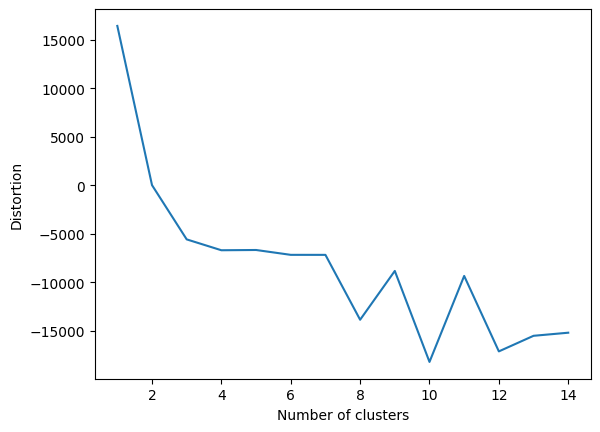

In [283]:
icl_scores_advanced_w = []

for i in np.arange(1, 15):
    gmm = GaussianMixture(n_components=i,
                          covariance_type='full',
                          random_state=RANDOM_STATE)
    gmm.fit(X_clustering_scaled_advanced_w)
    bic = gmm.bic(X_clustering_scaled_advanced_w)
    probs = gmm.predict_proba(X_clustering_scaled_advanced_w)
    probs_clipped = np.clip(probs, 1e-10, 1)
    entropy = -np.sum(probs_clipped * np.log(probs_clipped))
    icl = bic + 2 * entropy
    icl_scores_advanced_w.append(icl)

best_k_icl_advanced_w = list(range(1, 15))[np.argmin(icl_scores_advanced_w)]
print(f"best K (ICL): {best_k_icl_advanced_w}")

plt.plot(np.arange(1, 15), icl_scores_advanced_w)
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

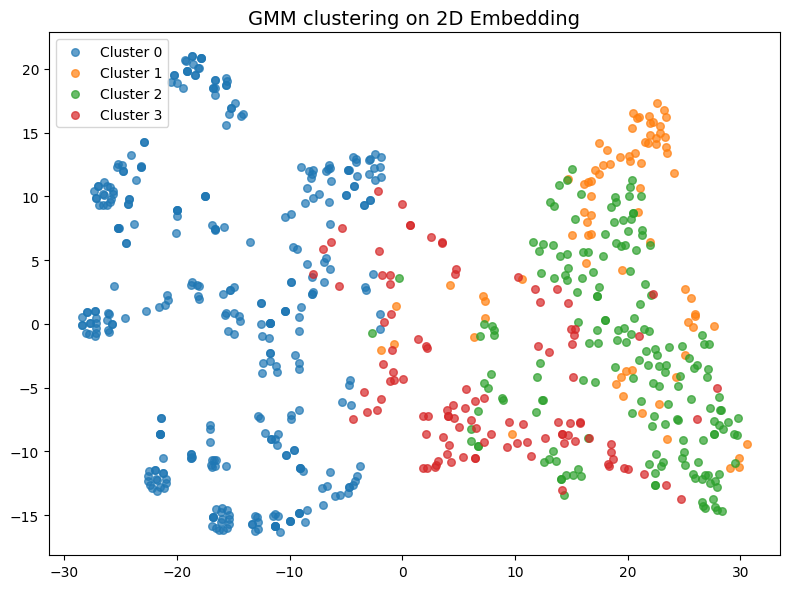

In [284]:
gmm_advanced_w = GaussianMixture(n_components=4, covariance_type='full', random_state=RANDOM_STATE)
gmm_labels_advanced_w = gmm_advanced_w.fit_predict(X_clustering_weighted_advanced_w)
plot_clustering(X_tsne_advanced_w, gmm_labels_advanced_w, centroids=[])

In [285]:
archetype_labels_advanced_w = gmm_labels_advanced_w
archetype_summary_advanced_w = X_advanced_w.copy()
archetype_summary_advanced_w['ARCHETYPE'] = archetype_labels_advanced_w

advanced_stats_to_show = [
    'SCORED', 'DEFENCE', 'CAUGHT', 'DROPPED',
    '%SHOT_SCORED', 'OFF_DEF_RATIO', 'CATCH_EFFICIENCY', 'NET_POINTS'
]

mean_statlines_advanced_w = archetype_summary_advanced_w.groupby('ARCHETYPE')[advanced_stats_to_show].mean().round(2)
mean_statlines_advanced_w['PLAYERS_COUNT'] = archetype_summary_advanced_w['ARCHETYPE'].value_counts()
mean_statlines_advanced_w

,SCORED,DEFENCE,CAUGHT,DROPPED,%SHOT_SCORED,OFF_DEF_RATIO,CATCH_EFFICIENCY,NET_POINTS,PLAYERS_COUNT
ARCHETYPE,,,,,,,,,
0,0.00,0.49,3.36,1.85,5.20,0.00,0.46,-0.09,337
1,8.45,9.66,6.58,3.60,33.81,1.80,0.57,6.30,79
2,4.72,4.71,2.44,2.50,44.49,1.92,0.40,4.10,178
3,1.90,2.07,6.08,4.47,39.81,0.81,0.42,1.34,107


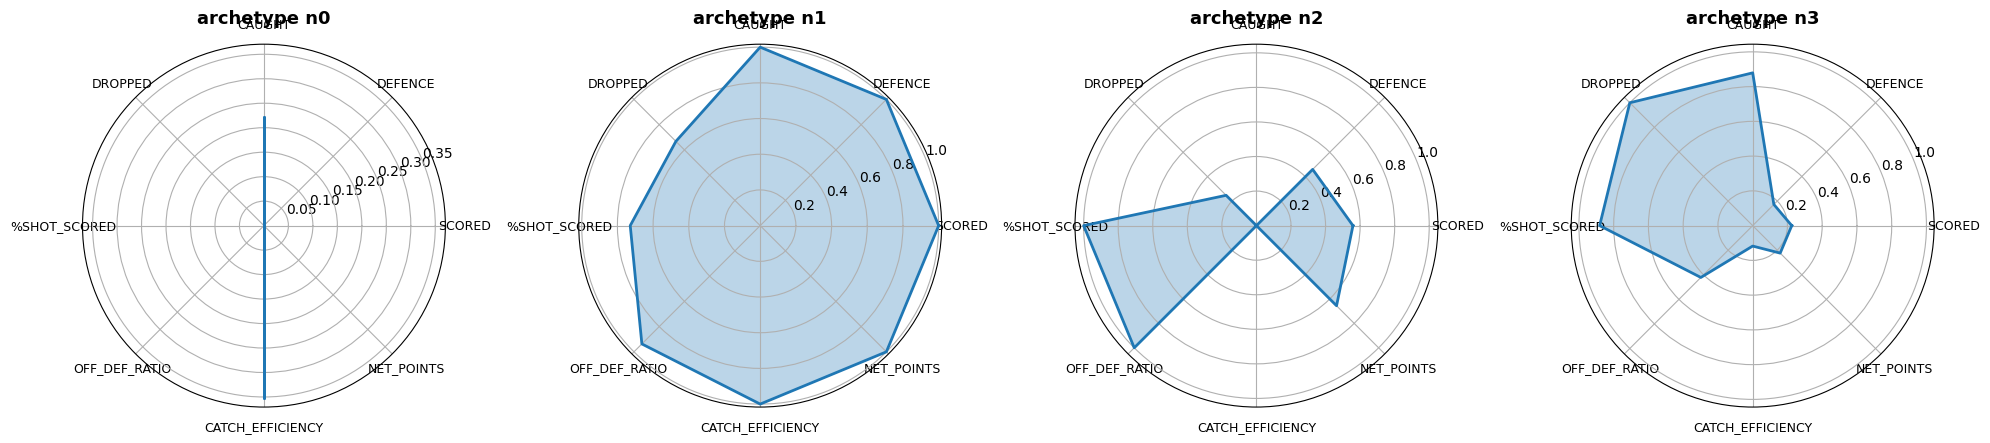

In [286]:
plot_archetype_radar(mean_statlines_advanced_w[advanced_stats_to_show])

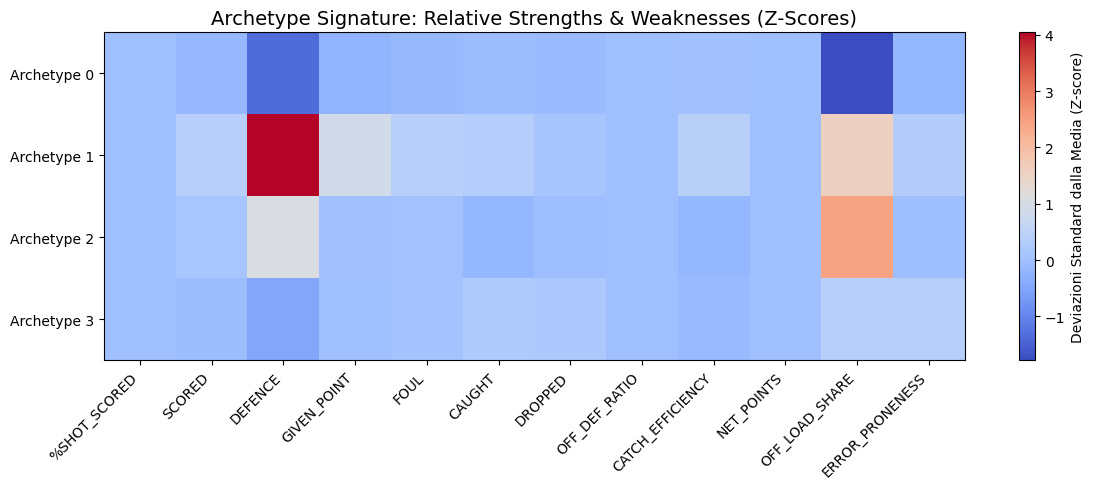

In [287]:
# Calcolo Z-Score medio per archetipo
z_scores_advanced_w = pd.DataFrame(X_clustering_weighted_advanced_w, columns=X_clustering_df_advanced_w.columns)
z_scores_advanced_w['ARCHETYPE'] = archetype_labels_advanced_w
archetype_z_advanced_w = z_scores_advanced_w.groupby('ARCHETYPE').mean()

plt.figure(figsize=(12, 5))
plt.imshow(archetype_z_advanced_w.values, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Deviazioni Standard dalla Media (Z-score)')
plt.xticks(range(len(archetype_z_advanced_w.columns)), archetype_z_advanced_w.columns, rotation=45, ha='right')
plt.yticks(range(len(archetype_z_advanced_w)), [f"Archetype {i}" for i in range(len(archetype_z_advanced_w))])
plt.title("Archetype Signature: Relative Strengths & Weaknesses (Z-Scores)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
X_w = X[X['SEX'] == 1]

X_clustering_df_w = cls.named_steps['trans'].transform(X_w)
X_clustering_df_w = X_clustering_df_w.drop(['SEX'], axis = 1)
X_clustering_scaled_w = np.asarray(X_clustering_df_w)
weights_no_sex = weights[:-1]
X_clustering_weighted_w = X_clustering_scaled_w * np.sqrt(weights_no_sex)

In [289]:
X_tsne_w = TSNE(
    n_components=2,
    init='pca',
    learning_rate='auto',
    max_iter=500,
    random_state=RANDOM_STATE
).fit_transform(X_clustering_weighted_w)

X_tsne_w

,tsne0,tsne1
0,25.330063,-6.529961
1,-14.926403,-1.486925
2,19.706087,-12.344296
3,2.265419,20.870419
4,13.134883,-3.072445
...,...,...
696,-14.279923,-21.957096
697,-16.320417,-18.732294
698,-16.975611,-17.802113
699,-16.975460,-17.802147


best K (ICL): 8


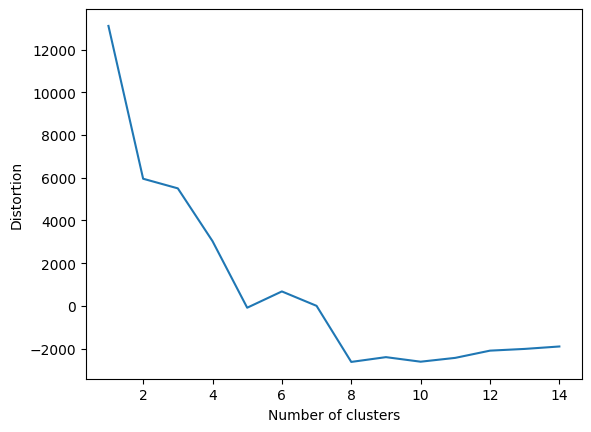

In [290]:
icl_scores_w = []

for i in np.arange(1, 15):
    gmm = GaussianMixture(n_components=i,
                          covariance_type='full',
                          random_state=RANDOM_STATE)
    gmm.fit(X_clustering_scaled_w)
    bic = gmm.bic(X_clustering_scaled_w)
    probs = gmm.predict_proba(X_clustering_scaled_w)
    probs_clipped = np.clip(probs, 1e-10, 1)
    entropy = -np.sum(probs_clipped * np.log(probs_clipped))
    icl = bic + 2 * entropy
    icl_scores_w.append(icl)

best_k_icl_w = list(range(1, 15))[np.argmin(icl_scores_w)]
print(f"best K (ICL): {best_k_icl_w}")

plt.plot(np.arange(1, 15), icl_scores_w)
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

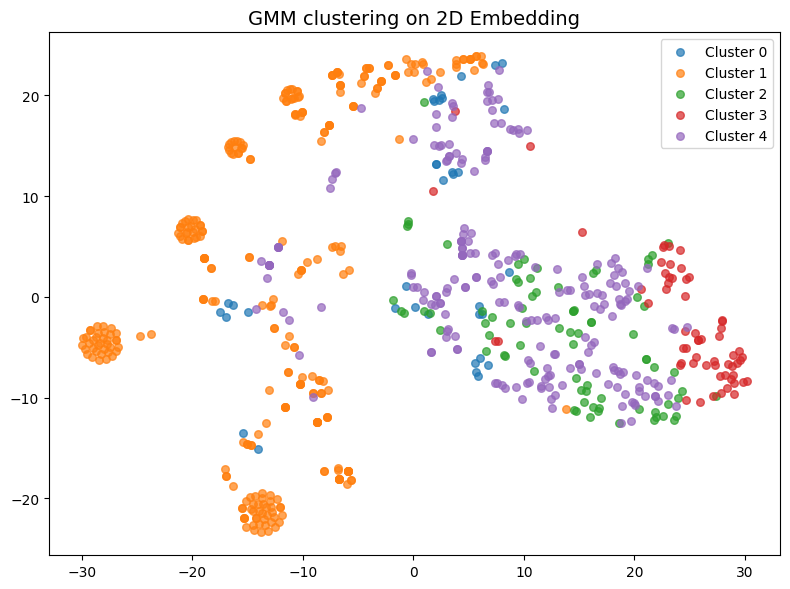

In [291]:
gmm_w = GaussianMixture(n_components=5, covariance_type='full', random_state=RANDOM_STATE)
gmm_labels_w = gmm_w.fit_predict(X_clustering_weighted_w)
plot_clustering(X_tsne_w, gmm_labels_w, centroids=[])

In [292]:
archetype_labels_w = gmm_labels_w
archetype_summary_w = X_w.copy()
archetype_summary_w['ARCHETYPE'] = archetype_labels_w

stats_to_show = [
    'SCORED', 'DEFENCE', 'CAUGHT', 'DROPPED', '%SHOT_SCORED'
]

mean_statlines_w = archetype_summary_w.groupby('ARCHETYPE')[stats_to_show].mean().round(2)
mean_statlines_w['PLAYERS_COUNT'] = archetype_summary_w['ARCHETYPE'].value_counts()
mean_statlines_w

,SCORED,DEFENCE,CAUGHT,DROPPED,%SHOT_SCORED,PLAYERS_COUNT
ARCHETYPE,,,,,,
0,2.10,1.74,6.77,3.35,27.97,35
1,0.00,0.46,3.48,1.83,0.00,306
2,5.07,5.14,2.59,2.66,34.83,78
3,9.75,10.66,6.19,3.55,35.38,61
4,3.53,3.51,3.94,3.46,46.09,221


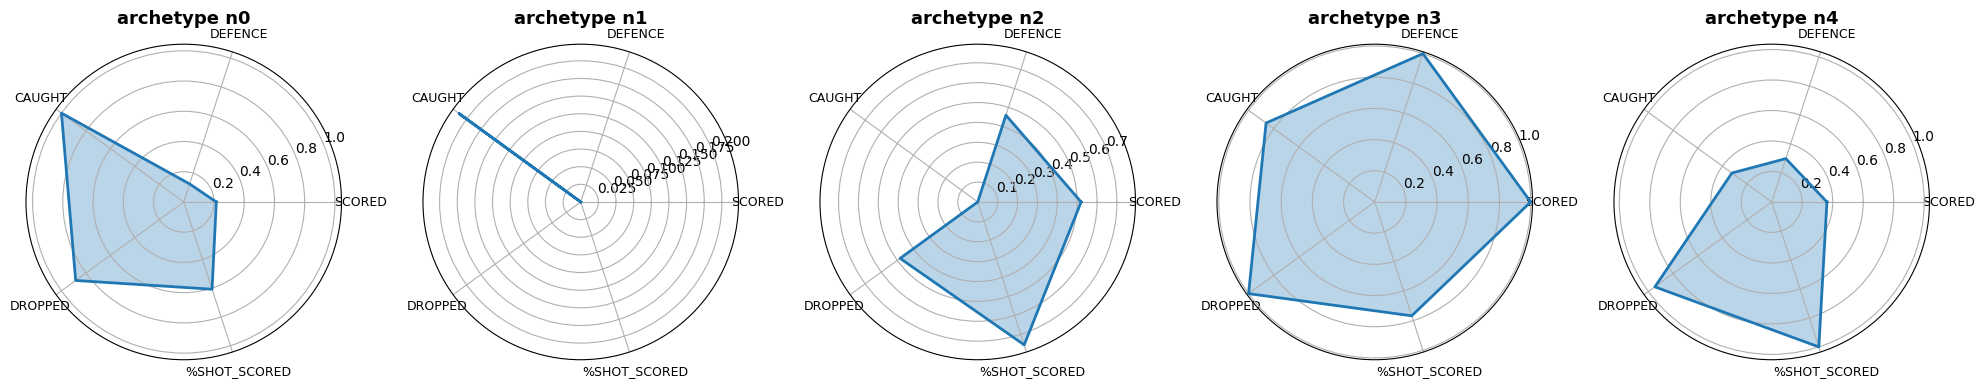

In [293]:
plot_archetype_radar(mean_statlines_w[stats_to_show])

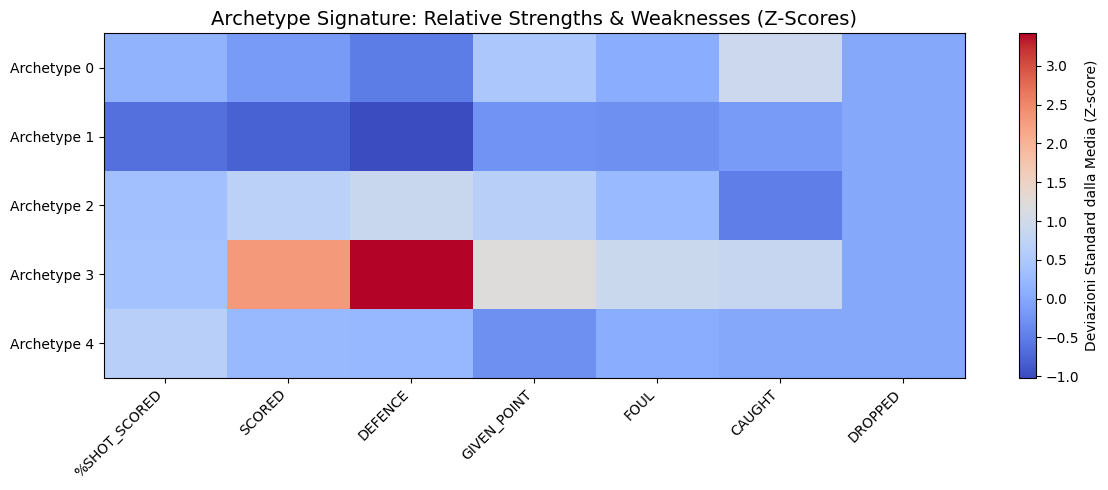

In [294]:
# Calcolo Z-Score medio per archetipo
z_scores_w = pd.DataFrame(X_clustering_weighted_w, columns=X_clustering_df_w.columns)
z_scores_w['ARCHETYPE'] = archetype_labels_w
archetype_z_w = z_scores_w.groupby('ARCHETYPE').mean()

plt.figure(figsize=(12, 5))
plt.imshow(archetype_z_w.values, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Deviazioni Standard dalla Media (Z-score)')
plt.xticks(range(len(archetype_z_w.columns)), archetype_z_w.columns, rotation=45, ha='right')
plt.yticks(range(len(archetype_z_w)), [f"Archetype {i}" for i in range(len(archetype_z_w))])
plt.title("Archetype Signature: Relative Strengths & Weaknesses (Z-Scores)", fontsize=14)
plt.tight_layout()
plt.show()

###MEN

In [ ]:
X_advanced_m = X_advanced[X_advanced['SEX'] == 0]

X_clustering_df_advanced_m = cls_advanced.named_steps['trans'].transform(X_advanced_m)
X_clustering_df_advanced_m = X_clustering_df_advanced_m.drop(['SEX'], axis = 1)
X_clustering_scaled_advanced_m = np.asarray(X_clustering_df_advanced_m)
weights_advanced_no_sex = weights_advanced[:-1]
X_clustering_weighted_advanced_m = X_clustering_scaled_advanced_m * np.sqrt(weights_advanced_no_sex)

In [296]:
X_tsne_advanced_m = TSNE(
    n_components=2,
    init='pca',
    learning_rate='auto',
    max_iter=500,
    random_state=RANDOM_STATE
).fit_transform(X_clustering_weighted_advanced_m)

X_tsne_advanced_m

,tsne0,tsne1
0,-26.772678,14.711392
1,7.927056,-4.763152
2,24.424892,4.464753
3,27.504700,2.196592
4,-17.526964,-17.815447
...,...,...
1696,-20.955877,8.105012
1697,3.419827,-19.825720
1698,-1.538761,2.814762
1699,-36.177628,-1.590475


best K (ICL): 11


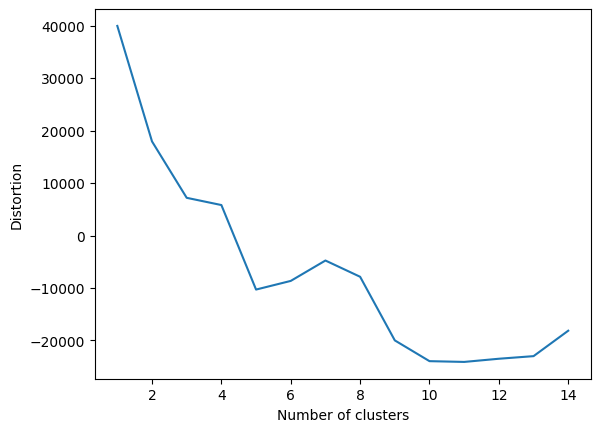

In [297]:
icl_scores_advanced_m = []

for i in np.arange(1, 15):
    gmm = GaussianMixture(n_components=i,
                          covariance_type='full',
                          random_state=RANDOM_STATE)
    gmm.fit(X_clustering_scaled_advanced_m)
    bic = gmm.bic(X_clustering_scaled_advanced_m)
    probs = gmm.predict_proba(X_clustering_scaled_advanced_m)
    probs_clipped = np.clip(probs, 1e-10, 1)
    entropy = -np.sum(probs_clipped * np.log(probs_clipped))
    icl = bic + 2 * entropy
    icl_scores_advanced_m.append(icl)

best_k_icl_advanced_m = list(range(1, 15))[np.argmin(icl_scores_advanced_m)]
print(f"best K (ICL): {best_k_icl_advanced_m}")

plt.plot(np.arange(1, 15), icl_scores_advanced_m)
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

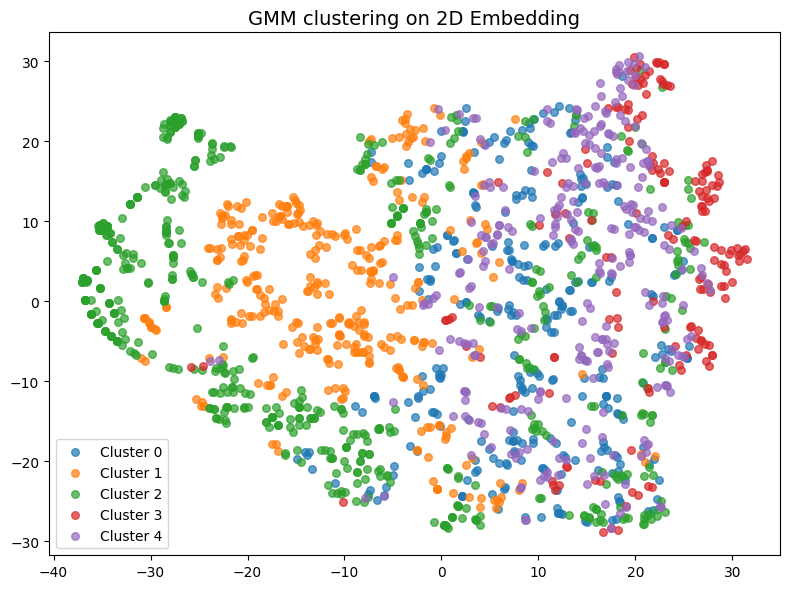

In [298]:
gmm_advanced_m = GaussianMixture(n_components=5, covariance_type='full', random_state=RANDOM_STATE)
gmm_labels_advanced_m = gmm_advanced_m.fit_predict(X_clustering_weighted_advanced_m)
plot_clustering(X_tsne_advanced_m, gmm_labels_advanced_m, centroids=[])

In [299]:
archetype_labels_advanced_m = gmm_labels_advanced_m
archetype_summary_advanced_m = X_advanced_m.copy()
archetype_summary_advanced_m['ARCHETYPE'] = archetype_labels_advanced_m

advanced_stats_to_show = [
    'SCORED', 'DEFENCE', 'CAUGHT', 'DROPPED',
    '%SHOT_SCORED', 'OFF_DEF_RATIO', 'CATCH_EFFICIENCY', 'NET_POINTS'
]

mean_statlines_advanced_m = archetype_summary_advanced_m.groupby('ARCHETYPE')[advanced_stats_to_show].mean().round(2)
mean_statlines_advanced_m['PLAYERS_COUNT'] = archetype_summary_advanced_m['ARCHETYPE'].value_counts()
mean_statlines_advanced_m

,SCORED,DEFENCE,CAUGHT,DROPPED,%SHOT_SCORED,OFF_DEF_RATIO,CATCH_EFFICIENCY,NET_POINTS,PLAYERS_COUNT
ARCHETYPE,,,,,,,,,
0,6.55,3.76,2.18,2.37,55.81,2.84,0.37,5.85,301
1,1.94,1.91,2.48,3.66,32.12,1.05,0.29,1.03,352
2,2.80,1.76,3.28,2.30,52.80,1.10,0.44,2.76,583
3,19.24,6.81,5.15,3.18,64.42,4.59,0.53,17.75,170
4,10.25,5.45,3.30,3.72,54.83,3.71,0.41,8.90,295


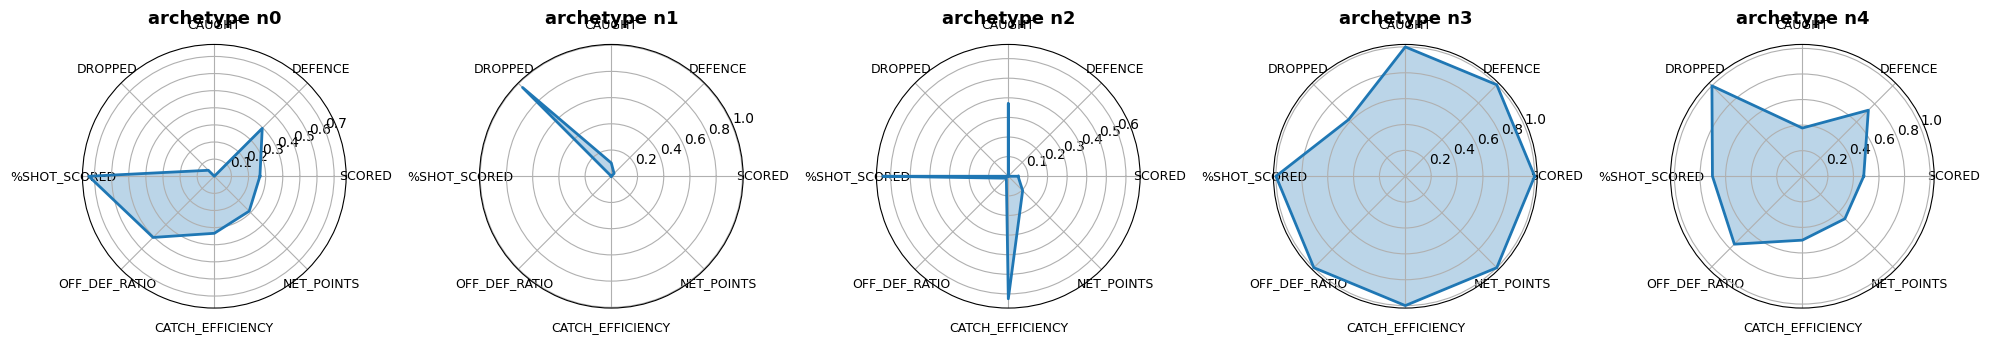

In [300]:
plot_archetype_radar(mean_statlines_advanced_m[advanced_stats_to_show])

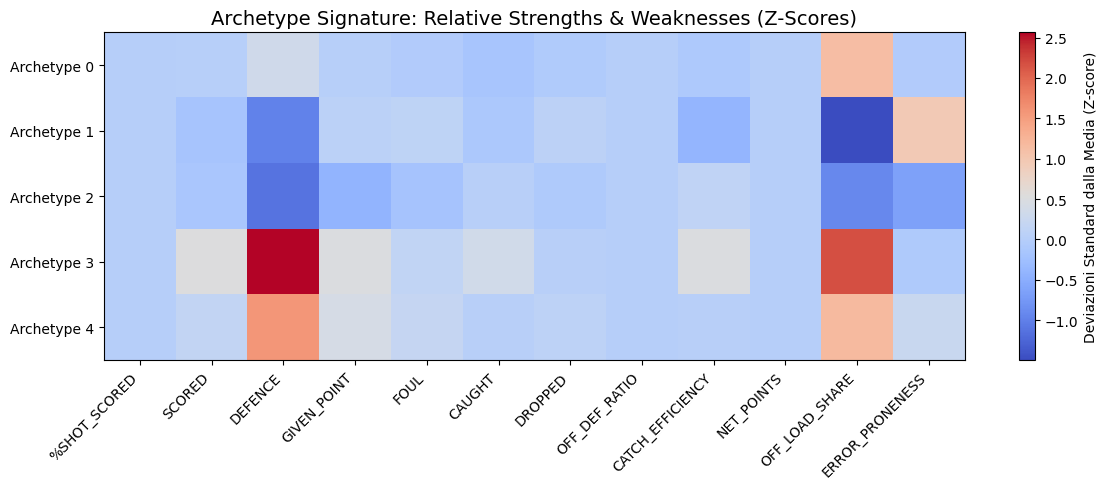

In [301]:
# Calcolo Z-Score medio per archetipo
z_scores_advanced_m = pd.DataFrame(X_clustering_weighted_advanced_m, columns=X_clustering_df_advanced_m.columns)
z_scores_advanced_m['ARCHETYPE'] = archetype_labels_advanced_m
archetype_z_advanced_m = z_scores_advanced_m.groupby('ARCHETYPE').mean()

plt.figure(figsize=(12, 5))
plt.imshow(archetype_z_advanced_m.values, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Deviazioni Standard dalla Media (Z-score)')
plt.xticks(range(len(archetype_z_advanced_m.columns)), archetype_z_advanced_m.columns, rotation=45, ha='right')
plt.yticks(range(len(archetype_z_advanced_m)), [f"Archetype {i}" for i in range(len(archetype_z_advanced_m))])
plt.title("Archetype Signature: Relative Strengths & Weaknesses (Z-Scores)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
X_m = X[X['SEX'] == 0]

X_clustering_df_m = cls.named_steps['trans'].transform(X_m)
X_clustering_df_m = X_clustering_df_m.drop(['SEX'], axis = 1)
X_clustering_scaled_m = np.asarray(X_clustering_df_m)
weights_no_sex = weights[:-1]
X_clustering_weighted_m = X_clustering_scaled_m * np.sqrt(weights_no_sex)

In [303]:
X_tsne_m = TSNE(
    n_components=2,
    init='pca',
    learning_rate='auto',
    max_iter=500,
    random_state=RANDOM_STATE
).fit_transform(X_clustering_weighted_m)

X_tsne_m

,tsne0,tsne1
0,-30.831638,5.150138
1,3.869944,22.231869
2,21.807240,-10.752629
3,15.111515,-0.291820
4,-17.788525,-1.418530
...,...,...
1696,-29.008469,14.764420
1697,0.550261,0.921123
1698,4.108084,-18.801254
1699,-29.181831,11.805565


best K (ICL): 12


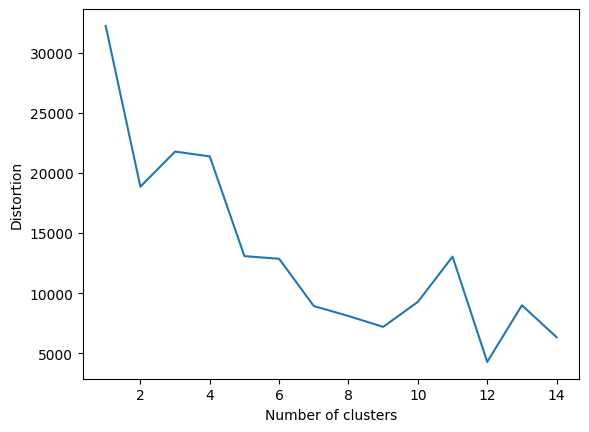

In [304]:
icl_scores_m = []

for i in np.arange(1, 15):
    gmm = GaussianMixture(n_components=i,
                          covariance_type='full',
                          random_state=RANDOM_STATE)
    gmm.fit(X_clustering_scaled_m)
    bic = gmm.bic(X_clustering_scaled_m)
    probs = gmm.predict_proba(X_clustering_scaled_m)
    probs_clipped = np.clip(probs, 1e-10, 1)
    entropy = -np.sum(probs_clipped * np.log(probs_clipped))
    icl = bic + 2 * entropy
    icl_scores_m.append(icl)

best_k_icl_m = list(range(1, 15))[np.argmin(icl_scores_m)]
print(f"best K (ICL): {best_k_icl_m}")

plt.plot(np.arange(1, 15), icl_scores_m)
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

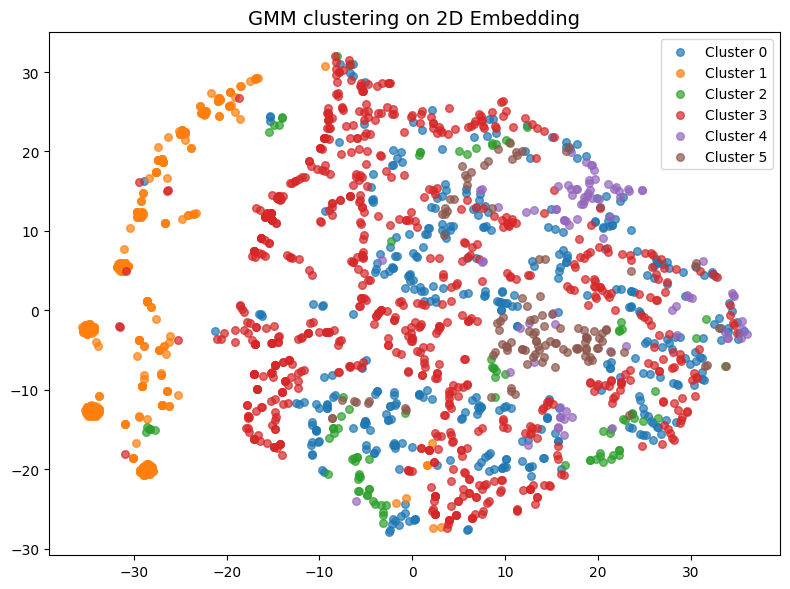

In [305]:
gmm_m = GaussianMixture(n_components=6, covariance_type='full', random_state=RANDOM_STATE)
gmm_labels_m = gmm_m.fit_predict(X_clustering_weighted_m)
plot_clustering(X_tsne_m, gmm_labels_m, centroids=[])

In [306]:
archetype_labels_m = gmm_labels_m
archetype_summary_m = X_m.copy()
archetype_summary_m['ARCHETYPE'] = archetype_labels_m

stats_to_show = [
    'SCORED', 'DEFENCE', 'CAUGHT', 'DROPPED', '%SHOT_SCORED'
]

mean_statlines_m = archetype_summary_m.groupby('ARCHETYPE')[stats_to_show].mean().round(2)
mean_statlines_m['PLAYERS_COUNT'] = archetype_summary_m['ARCHETYPE'].value_counts()
mean_statlines_m

,SCORED,DEFENCE,CAUGHT,DROPPED,%SHOT_SCORED,PLAYERS_COUNT
ARCHETYPE,,,,,,
0,8.17,4.45,2.88,2.92,53.10,393
1,0.00,0.47,3.38,2.73,0.00,268
2,3.74,3.87,2.81,2.30,32.91,98
3,5.54,2.99,3.20,2.90,58.88,743
4,20.00,7.25,3.34,4.29,61.22,86
5,11.44,4.61,2.96,3.12,57.56,113


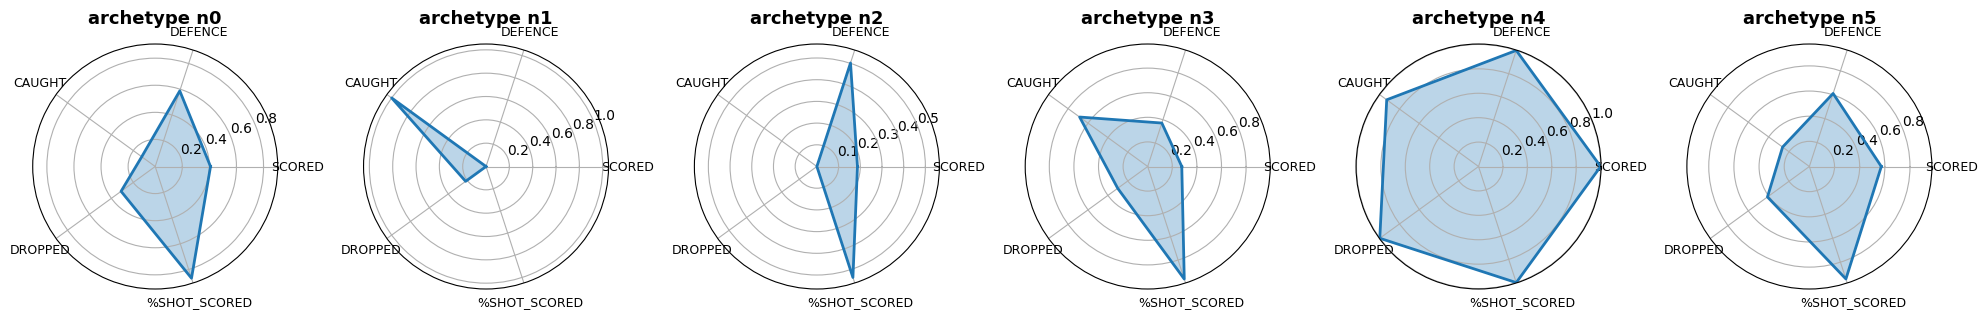

In [307]:
plot_archetype_radar(mean_statlines_m[stats_to_show])

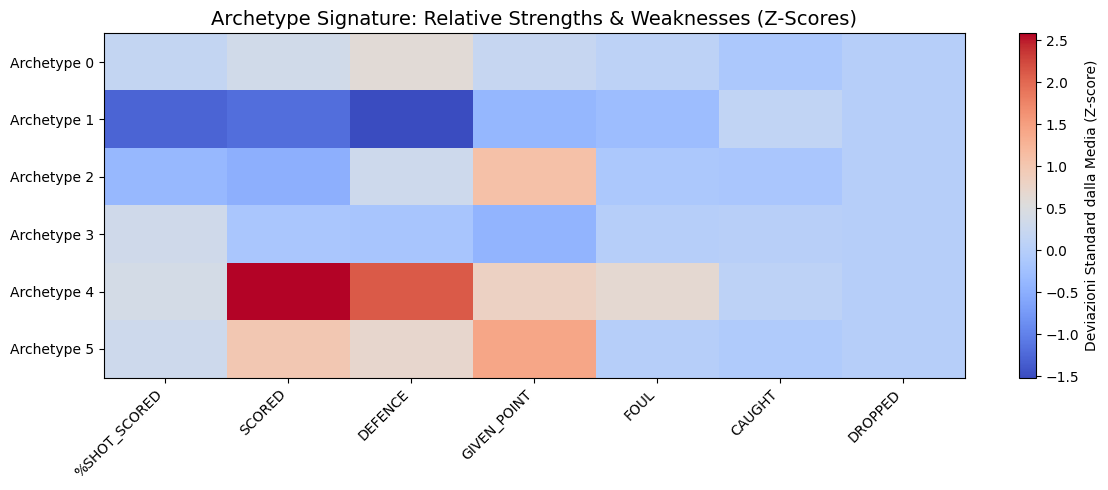

In [308]:
# Calcolo Z-Score medio per archetipo
z_scores_m = pd.DataFrame(X_clustering_weighted_m, columns=X_clustering_df_m.columns)
z_scores_m['ARCHETYPE'] = archetype_labels_m
archetype_z_m = z_scores_m.groupby('ARCHETYPE').mean()

plt.figure(figsize=(12, 5))
plt.imshow(archetype_z_m.values, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Deviazioni Standard dalla Media (Z-score)')
plt.xticks(range(len(archetype_z_m.columns)), archetype_z_m.columns, rotation=45, ha='right')
plt.yticks(range(len(archetype_z_m)), [f"Archetype {i}" for i in range(len(archetype_z_m))])
plt.title("Archetype Signature: Relative Strengths & Weaknesses (Z-Scores)", fontsize=14)
plt.tight_layout()
plt.show()

## SAVE THE MODELS

In [309]:
import joblib

# Salvataggio della pipeline di classificazione e del GMM
joblib.dump(cls, 'models/trained_pipeline.joblib')
joblib.dump(cls_advanced, 'models/trained_pipeline_advanced.joblib')
joblib.dump(gmm, 'models/gmm_archetypes.joblib')
joblib.dump(gmm_w, 'models/gmm_w_archetypes.joblib')
joblib.dump(gmm_m, 'models/gmm_m_archetypes.joblib')
joblib.dump(gmm_advanced, 'models/gmm_advanced_archetypes.joblib')
joblib.dump(gmm_advanced_w, 'models/gmm_advanced_w_archetypes.joblib')
joblib.dump(gmm_advanced_m, 'models/gmm_advanced_m_archetypes.joblib')

['models/gmm_advanced_m_archetypes.joblib']